# Exponential Trend Smoothing

:::{attention}
This notebook uses libraries that are not PyMC dependencies
and therefore need to be installed specifically to run this notebook.
Open the dropdown below for extra guidance.
:::

::::::{dropdown} Extra dependencies install instructions
:icon: package-dependencies
In order to run this notebook (either locally or on binder) you won't only
need a working PyMC installation with all optional dependencies,
but also to install some extra dependencies.
For advise on installing PyMC itself, please refer to {ref}`pymc:installation`

You can install these dependencies with your preferred package manager, we provide
as an example the pip and conda commands below.

> $ pip install kuznets nutpie ipywidgets

Note that if you want (or need) to install the packages from inside the notebook instead
of the command line, you can install
the packages by running a variation of the pip command:

> import sys
>
> !{sys.executable} -m pip install kuznets nutpie ipywidgets

You should not run `!pip install` as it might install the package in a different
environment and not be available from the Jupyter notebook even if installed.

Another alternative is using conda instead:

> $ conda install kuznets nutpie ipywidgets

when installing scientific python packages with conda,
we recommend using [conda forge](https://conda-forge.org/index.html)
::::::

Exponential Trend Smoothing (ETS) models are a powerful family of timeseries models purpose built for forecasting. The early researchers on these models -- [Brown (1959)](#Brown1959), [Holt (1957)](#Holt1957), and [Winters (1960)](#Winters1960) -- were concerned first and foremost with forecasting. [Forecasting: Principles and Practice, Chapter 8](https://otexts.com/fpp3/expsmooth.html) should be regarded as the first and last word on these methods. This presentation draws heavily on that chapter, and it should be consulted for a deeper understanding of the ETS method.

ETS begins from a simple proposition: the future should look like the past. This is a common enough proposition in time series modeling -- all models end up using past observations as "features" in the models. The question is "which past should be used?".

### Setup

Imports, sampler settings, and the plotting helpers used throughout the notebook.

In [1]:
from functools import partial
from pathlib import Path

import arviz as az
import ipywidgets as widgets
import kuznets
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import preliz as pz
import pymc as pm
import pytensor
import pytensor.tensor as pt
import xarray as xr

from IPython.display import display
from matplotlib.dates import DateFormatter, DayLocator, MonthLocator, YearLocator
from matplotlib.figure import Figure
from pymc.pytensorf import inputvars

import pymc_extras.statespace as pmss

from pymc_extras.statespace.filters.distributions import LinearGaussianStateSpace

plt.rcParams.update(
    {
        "figure.figsize": (14, 4),
        "figure.dpi": 144,
        "figure.facecolor": "w",
        "axes.grid": True,
        "grid.linewidth": 0.5,
        "grid.linestyle": "--",
        "axes.spines.top": False,
        "axes.spines.bottom": False,
        "axes.spines.left": False,
        "axes.spines.right": False,
        "figure.constrained_layout.use": True,
    }
)

In [2]:
SAMPLER_KWARGS = {
    "nuts_sampler": "nutpie",
    "chains": 8,
    "cores": 8,
    "tune": 500,
    "draws": 250,
}

# Credible-interval width, named once and passed to every `az.hdi` call so that the figure
# labels cannot drift from the interval they describe.
CI_PROB = 0.89
CI_LABEL = f"{CI_PROB:.0%} HDI"

In [3]:
def make_update_plot(
    close_data: pd.Series,
    f_ets,
    f_forecast,
    n_draws: int = 100,
    include_trend: bool = False,
    include_phi: bool = False,
    draw_lines: bool = True,
):
    """
    Build the callback that redraws the in-sample fit and forecast for one slider setting.

    Parameters
    ----------
    close_data : pandas.Series
        Training data, indexed by date.
    f_ets : callable
        Compiled function mapping ETS parameters to the predicted state means and covariances.
    f_forecast : callable
        Compiled function drawing one 30-step-ahead forecast path from the ETS parameters.
    n_draws : int, optional
        Number of forecast paths to average into the plotted forecast band. Default 100.
    include_trend : bool, optional
        Draw a second panel with the trend state. Default False.
    include_phi : bool, optional
        Treat the trend dampening ``phi`` as a slider rather than pinning it to 1. Default False.
    draw_lines : bool, optional
        Draw the random-walk and sample-mean forecasts as reference lines. Default True.

    Returns
    -------
    update_plot : callable
        Function taking ETS parameters as keyword arguments and drawing the figure.
    """

    def update_plot(**kwargs):
        initial_state_cov = np.eye(2 + int(include_trend))

        if include_trend and not include_phi:
            kwargs["phi"] = 1.0

        mu, cov = f_ets(**kwargs, initial_state_cov=initial_state_cov)

        x_vals = close_data.index
        x_forecast = close_data.index.shift(30)[-30:]

        if include_trend:
            fig, axes = plt.subplots(2, 1, figsize=(14, 6), dpi=144)
            ax = axes[0]
            trend_ax = axes[1]
        else:
            fig, ax = plt.subplots(figsize=(14, 4), dpi=144)

        ax.plot(x_vals, mu[:, 1], label="Prediction")
        ax.plot(x_vals, close_data.values, label="Data", ls="--", c="k")

        ax.fill_between(
            x_vals,
            mu[:, 1] - 1.96 * np.sqrt(cov[:, 1, 1]),
            mu[:, 1] + 1.96 * np.sqrt(cov[:, 1, 1]),
            alpha=0.25,
            label="In-Sample 95%",
        )

        ax.set_title("Observed Component", loc="left")

        if include_trend:
            trend_ax.plot(x_vals, mu[:, 2], label="Trend")
            trend_ax.plot(
                x_vals,
                close_data.diff().values,
                label="Data First Difference",
                ls="--",
                c="k",
                lw=0.5,
            )
            trend_ax.fill_between(
                x_vals,
                mu[:, 2] - 1.96 * np.sqrt(cov[:, 2, 2]),
                mu[:, 2] + 1.96 * np.sqrt(cov[:, 2, 2]),
                alpha=0.25,
                label="In-Sample 95%",
            )

            trend_ax.set_title("Trend Component", loc="left")
            trend_ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0), frameon=False)

        draw_forecast = partial(f_forecast, **kwargs, initial_state_cov=initial_state_cov)

        forecast_draws = np.array([draw_forecast().ravel() for _ in range(n_draws)])
        mu_forecast = forecast_draws.mean(axis=0)
        var_forecast = forecast_draws.var(axis=0)

        ax.plot(x_forecast, mu_forecast[1:], label="Forecast")
        ax.fill_between(
            x_forecast,
            mu_forecast[1:] - 1.96 * np.sqrt(var_forecast[:-1]),
            mu_forecast[1:] + 1.96 * np.sqrt(var_forecast[:-1]),
            alpha=0.25,
            color="tab:orange",
            label="Forecast 95%",
        )

        if draw_lines:
            ax.axhline(close_data.values[-1], ls="--", c="tab:green", label="Random Walk Forecast")
            ax.axhline(close_data.mean().item(), ls="--", c="tab:red", label="Mean Forecast")

        handles, labels = ax.get_legend_handles_labels()
        fig.legend(
            handles=handles,
            labels=labels,
            loc="lower center",
            bbox_to_anchor=(0.5, -0.08),
            ncol=len(labels),
            frameon=False,
        )
        plt.show()

    return update_plot

In [4]:
def mod_to_functions(mod, df: pd.DataFrame, forecast_steps: int = 30):
    """
    Compile the in-sample and forecast graphs of an ETS model as plain callables.

    Parameters
    ----------
    mod : BayesianETS
        Model supplying the statespace matrices, with its parameters left as placeholders.
    df : pandas.DataFrame
        Training data, with the observed series in a ``Close`` column.
    forecast_steps : int, optional
        Length of the forecast horizon. Default 30.

    Returns
    -------
    f_ets : callable
        Maps ETS parameters to the predicted state means and covariances.
    f_forecast : callable
        Draws one forecast path of length ``forecast_steps`` from the ETS parameters.
    """
    kalman_filter, _ = mod.make_filters()
    filter_outputs = kalman_filter.build_graph(
        pt.as_tensor_variable(df.Close.values[:, None]),
        *mod._unpack_statespace_with_placeholders(),
    )
    (
        filtered_states,
        predicted_states,
        observed_states,
        filtered_covariances,
        predicted_covariances,
        observed_covariances,
        loglike_obs,
    ) = filter_outputs

    # The last in-sample state and covariance are the initial conditions of the forecast.
    x0, Sigma0 = filtered_states[-1], filtered_covariances[-1]

    _, obs_forecast = LinearGaussianStateSpace.dist(
        x0, Sigma0, *mod._unpack_statespace_with_placeholders()[2:], steps=forecast_steps
    )

    f_ets = pytensor.function(
        inputvars(predicted_states), [predicted_states, predicted_covariances]
    )

    # The forecast is a distribution rather than a closed-form moment, so the mean and variance
    # come from repeated draws.
    f_forecast = pm.compile(inputvars(obs_forecast), obs_forecast)

    return f_ets, f_forecast

In [5]:
def make_interactive_plot(
    mod,
    df_train: pd.DataFrame,
    include_trend: bool = False,
    include_phi: bool = False,
    draw_lines: bool = True,
    n_draws: int = 100,
):
    """
    Build the slider widget that redraws the ETS fit and forecast as parameters change.

    Parameters
    ----------
    mod : BayesianETS
        Model supplying the statespace matrices, with its parameters left as placeholders.
    df_train : pandas.DataFrame
        Training data, with the observed series in a ``Close`` column.
    include_trend : bool, optional
        Expose the trend parameters and draw the trend panel. Default False.
    include_phi : bool, optional
        Expose the trend dampening ``phi``. Default False.
    draw_lines : bool, optional
        Draw the random-walk and sample-mean forecasts as reference lines. Default True.
    n_draws : int, optional
        Number of forecast paths to average into the plotted forecast band. Default 100.

    Returns
    -------
    widget : ipywidgets.Widget
        Interactive widget wrapping the sliders and the plot callback.
    """
    f_ets, f_forecast = mod_to_functions(mod, df_train)

    update_plot = make_update_plot(
        close_data=df_train.Close,
        f_ets=f_ets,
        f_forecast=f_forecast,
        n_draws=n_draws,
        include_trend=include_trend,
        include_phi=include_phi,
        draw_lines=draw_lines,
    )

    alpha_slider = widgets.FloatSlider(
        value=0.99, min=1e-6, max=1 - 1e-6, step=0.01, description="Alpha:"
    )
    beta_slider = widgets.FloatSlider(
        value=0.0, min=1e-6, max=1 - 1e-6, step=0.01, description="Beta:"
    )
    phi_slider = widgets.FloatSlider(value=1.0, min=0.8, max=1, step=0.01, description="Phi:")

    sigma_slider = widgets.FloatSlider(
        value=1.0, min=0.1, max=10.0, step=0.1, description="Sigma State:"
    )

    initial_level_slider = widgets.FloatSlider(
        value=df_train.Close.values[0], min=0, max=100.0, step=0.1, description="Initial Level:"
    )
    initial_trend_slider = widgets.FloatSlider(
        value=0, min=-10, max=10, step=0.1, description="Initial Trend:"
    )

    kwargs = {
        "alpha": alpha_slider,
        "sigma_state": sigma_slider,
        "initial_level": initial_level_slider,
    }

    if include_trend:
        kwargs["beta"] = beta_slider
        kwargs["initial_trend"] = initial_trend_slider

    if include_phi:
        kwargs["phi"] = phi_slider

    preferred_order = ["alpha", "beta", "phi", "initial_level", "initial_trend", "sigma_state"]
    kwargs = {key: kwargs[key] for key in preferred_order if key in kwargs}

    return widgets.interactive(update_plot, **kwargs)

In [6]:
def plot_candlesticks(df: pd.DataFrame, lw: float = 0.5) -> Figure:
    """
    Draw a candlestick chart of daily prices with a trading-volume panel beneath it.

    Parameters
    ----------
    df : pandas.DataFrame
        Daily OHLCV data indexed by date, with ``Open``, ``High``, ``Low``, ``Close``, and
        ``Volume`` columns.
    lw : float, optional
        Line width of the candle bodies and wicks. Default 0.5.

    Returns
    -------
    figure : matplotlib.figure.Figure
        Figure holding the price axis and the volume axis, in that order.
    """
    delta = pd.Timedelta(hours=18)
    half_delta = pd.Timedelta(hours=9)

    fig = plt.figure()
    gs = plt.GridSpec(nrows=4, ncols=1, figure=fig)
    candlestick_ax = fig.add_subplot(gs[:-1, :])
    volume_ax = fig.add_subplot(gs[-1, :])

    # Draw the body
    candlestick_ax.hlines(df.Open, df.index - delta, df.index, lw=lw, color="k")
    candlestick_ax.hlines(df.Close, df.index - delta, df.index, lw=lw, color="k")
    candlestick_ax.vlines(df.index, df.Open, df.Close, lw=lw, color="k")
    candlestick_ax.vlines(df.index - delta, df.Open, df.Close, lw=lw, color="k")

    # Fill the bodies. A NaT is spliced after each candle so that fill_between treats every
    # candle as its own polygon rather than joining consecutive ones.
    color = (df.Close - df.Open).map(lambda x: "tab:red" if x < 0 else "tab:green")
    for candle_color in ["tab:red", "tab:green"]:
        color_mask = color == candle_color
        augmented_dates = np.column_stack(
            (
                df.index.values[color_mask],
                df.index.values[color_mask] - delta,
                np.full(color_mask.sum(), np.nan, dtype=np.datetime64),
            )
        )
        candlestick_ax.fill_between(
            augmented_dates.ravel(),
            df.Open.values[color_mask].repeat(3),
            df.Close.values[color_mask].repeat(3),
            color=candle_color,
            alpha=0.5,
        )

    # Draw the wick
    max_open_close = df[["Open", "Close"]].max(axis=1)
    min_open_close = df[["Open", "Close"]].min(axis=1)

    candlestick_ax.hlines(df.High, df.index - delta, df.index, lw=lw, color="k")
    candlestick_ax.hlines(df.Low, df.index - delta, df.index, lw=lw, color="k")
    candlestick_ax.vlines(df.index - half_delta, max_open_close, df.High, lw=lw, color="k")
    candlestick_ax.vlines(df.index - half_delta, min_open_close, df.Low, lw=lw, color="k")
    candlestick_ax.set(xticklabels=[], ylabel="Price (USD)")

    volume_ax.bar(df.index, df.Volume, color=color, alpha=0.5)
    volume_ax.bar(df.index, df.Volume, edgecolor="k", facecolor="none", lw=1)

    volume_ax.xaxis.set_major_locator(MonthLocator(interval=1))
    volume_ax.xaxis.set_minor_locator(DayLocator(interval=7))
    volume_ax.xaxis.set_major_formatter(DateFormatter("%b"))

    # Put the years on a second row under the months, so a year tick does not displace January.
    years = YearLocator()
    years_fmt = DateFormatter("%Y")
    xmin, _ = volume_ax.get_xlim()

    for year in years.tick_values(df.index.min(), df.index.max()):
        volume_ax.text(
            max(year, xmin),
            -0.6,
            years_fmt(year),
            transform=volume_ax.get_xaxis_transform(),
            ha="center",
            fontsize=9,
        )

    volume_ax.set(ylabel="Volume (shares)")

    return fig

In [7]:
def plot_decomposition(
    posterior: xr.DataArray,
    state_names: list[str],
    n_rows: int,
    n_cols: int,
    figsize: tuple[float, float] = (14, 6),
) -> Figure:
    """
    Draw the posterior mean and credible band of each hidden state on its own panel.

    Parameters
    ----------
    posterior : xarray.DataArray
        Posterior draws over the hidden states, with ``chain``, ``draw``, ``time``, and ``state``
        dimensions.
    state_names : list of str
        States to draw, one panel each. Panels are filled column by column.
    n_rows : int
        Number of panel rows.
    n_cols : int
        Number of panel columns.
    figsize : tuple of float, optional
        Figure size in inches. Default (14, 6).

    Returns
    -------
    figure : matplotlib.figure.Figure
        The completed figure.
    """
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize, sharex=True, squeeze=False)

    for axis, state in zip(axes.T.ravel(), state_names):
        component = posterior.sel(state=state)
        mu = component.mean(dim=["chain", "draw"])
        hdi = az.hdi(component, prob=CI_PROB)

        axis.plot(component.coords["time"], mu.values, label="Posterior Mean")
        axis.fill_between(component.coords["time"], *hdi.values.T, alpha=0.25, label=CI_LABEL)
        axis.set(xlabel="", ylabel="")
        axis.set_title(state.replace("_", " ").title(), loc="left")

    for axis in axes[-1, :]:
        axis.set(xlabel="Time")

    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(
        handles=handles,
        labels=labels,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.05),
        ncol=len(labels),
        frameon=False,
    )

    return fig

### The Data

We'll use some stock price data. Stock prices are notoriously hard to forecast, so it will be a nice testbed. Let's look at the hottest tech stock at the time of writing, Nvidia ($NVDA), manufacturer of GPUs used to train large language models (and, more importantly, to do ray-tracing in Minecraft mods).

In [8]:
# The download is cached so that re-running the notebook does not depend on Yahoo Finance being
# reachable, and so that the numbers below stay pinned to the window the text describes.
FORCE_UPDATE = False
END_DATE = pd.Timestamp("2024-08-10")

data_dir = Path("data")
data_dir.mkdir(exist_ok=True)
cache_path = data_dir / "nvda-1yr.parquet"

if not cache_path.exists() or FORCE_UPDATE:
    nvda = kuznets.DataReader(
        "NVDA", "yahoo", start=END_DATE - pd.Timedelta(days=365), end=END_DATE
    )
    nvda.to_parquet(cache_path)
else:
    nvda = pd.read_parquet(cache_path)

In [9]:
train_pct = 0.7
test_pct = 0.2
dev_pct = 0.1

assert np.allclose(train_pct + test_pct + dev_pct, 1.0)
T = nvda.shape[0]
range_idx = np.arange(T)
cutpoints = np.quantile(range_idx, np.cumsum([train_pct, test_pct, dev_pct])).astype(int)

train_end_date = nvda.index[cutpoints[0]]
test_end_date = nvda.index[cutpoints[1]]

df_train = nvda.loc[:train_end_date]
df_test = nvda.loc[train_end_date:test_end_date]
df_dev = nvda.loc[test_end_date:]

# Resample to business days so the index carries a frequency. This introduces missing values on
# days when the market is closed, which the Kalman filter handles by imputation.
df_train = df_train.resample("B").first()
df_train.index.freq = df_train.index.inferred_freq

Nvidia has been enjoying a crazy bull run for the last couple years. At the time of writing (Aug 10, 2024), though, there's been a huge pullback in technology stocks over the past few weeks. This notebook will hopefully end up as something of a cautionary tale about predicting stock prices: don't try!

Here is the candlestick plot for NVDA between August 2023 and June 2024. These are a favorite of so-called "technical analysts", who use them to look for patterns, which they then use to trade on and lose money (in expectation). Can you spot the head and shoulders formation? Me either. They are quite pretty though, and summarize a lot of information in an easy-to-read way.

Each "candlestick" is a day of trading activity. The size of the candlestick (the colored rectangle) is the size of the day's opening price minus the closing price. If it's red, the stock closed lower than it opened (went down over the day). Green means it went up over the day.

The "wick" shows the day's high and low price.

At the bottom is the daily trading volume: the number of transactions between buyers and sellers that took place over the course of the day. For a big popular stock like Nvidia, this is a big number: notice that the y-axis scale is in billions!

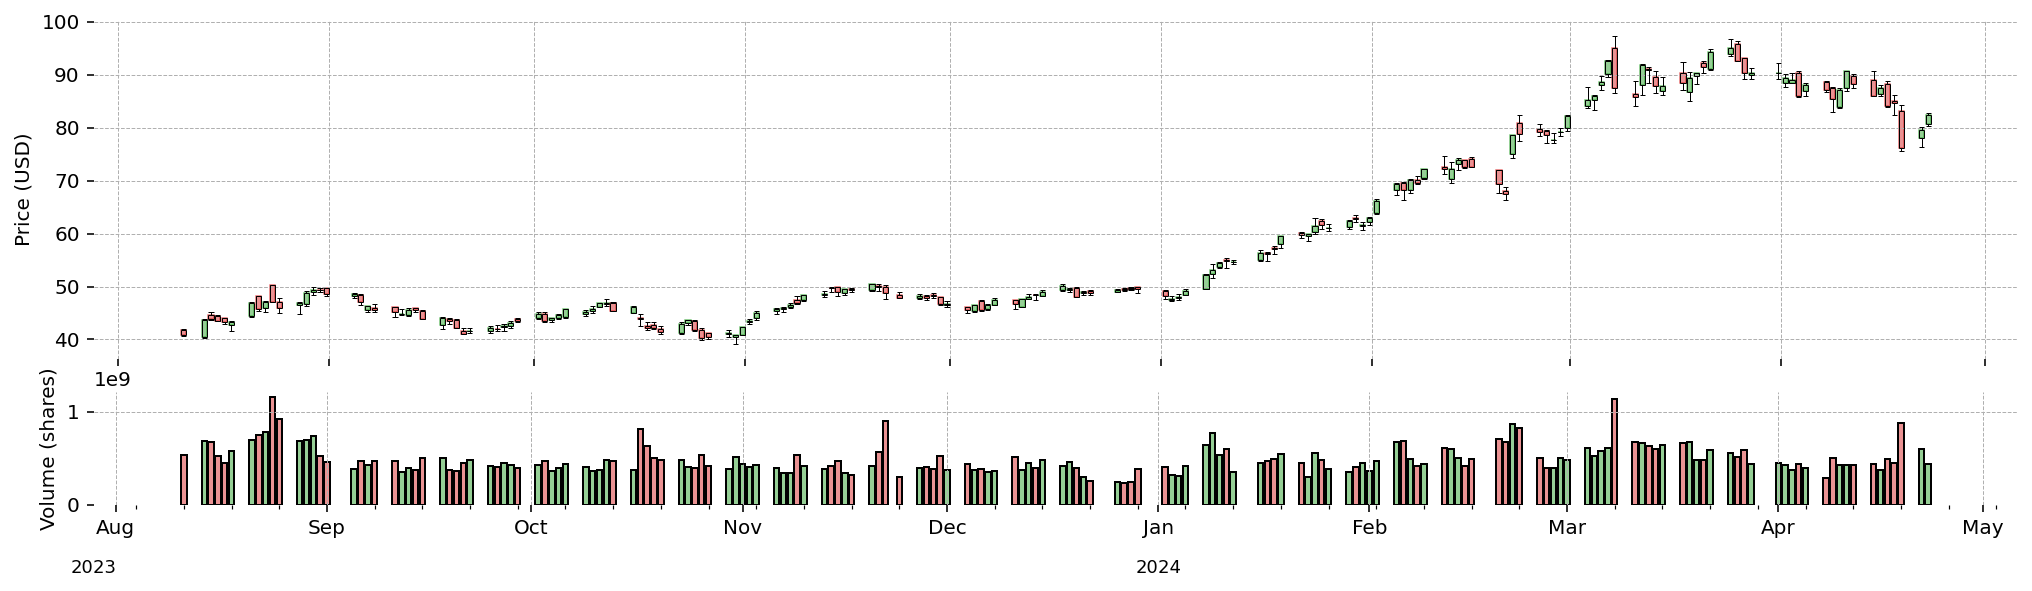

In [10]:
plot_candlesticks(df_train)
plt.show()

Zooming in on the last 50 days makes the candlesticks a bit easier to see:

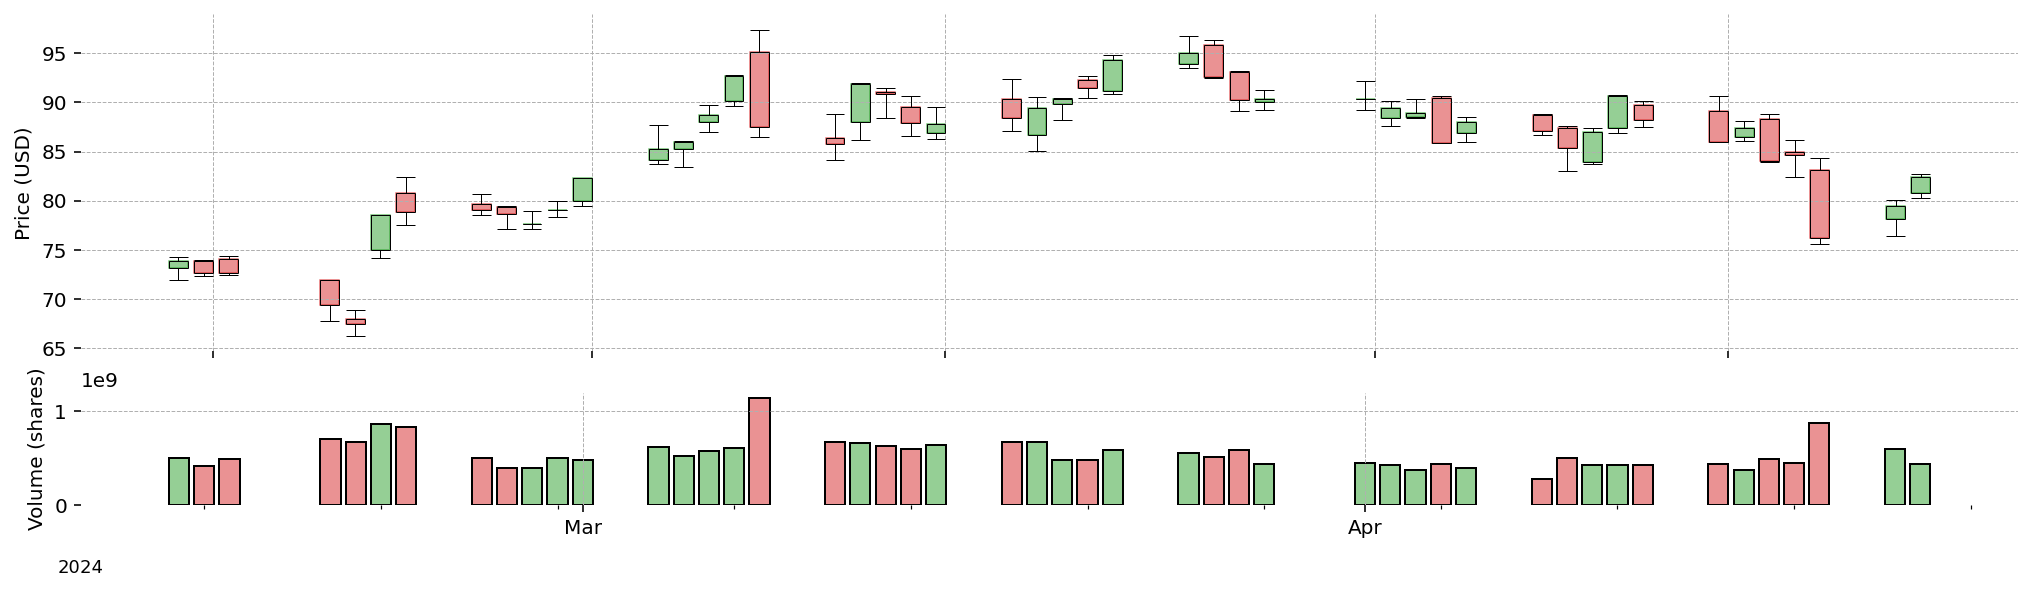

In [11]:
plot_candlesticks(df_train.tail(50))
plt.show()

Anyway, forecasting. We will use the past to predict the future. One idea might be that the future will look just like today. This isn't so crazy, it's the so-called "random walk" assumption. The implied statistical model is:

$$
\begin{aligned}
P_t &= P_{t-1} + \varepsilon_t \\
\varepsilon_t &\sim N(0, \sigma)
\end{aligned}
$$

Prices today are the same as prices yesterday (in expectation). This seems like a pretty bad assumption, as there appears to be a trend. Nevertheless, stock prices (actually log prices, but I elide this detail here) are believed to follow a gaussian random walk. So it should forecast well enough!

In [12]:
def plot_candlesticks_with_forecast(
    df_train: pd.DataFrame,
    df_test: pd.DataFrame,
    idata=None,
    idata_forecast=None,
    draw_rw: bool = False,
    draw_mean: bool = False,
) -> Figure:
    """
    Overlay in-sample fits, forecasts, and baseline forecasts on the candlestick chart.

    Parameters
    ----------
    df_train : pandas.DataFrame
        Training data, plotted as candlesticks.
    df_test : pandas.DataFrame
        Held-out data, plotted as a line so the forecast can be judged against it.
    idata : arviz.InferenceData, optional
        Conditional posterior carrying ``predicted_posterior_observed``. Omit to skip the
        in-sample band. Default None.
    idata_forecast : arviz.InferenceData, optional
        Forecast carrying ``forecast_observed``. Omit to skip the forecast band. Default None.
    draw_rw : bool, optional
        Draw the random-walk baseline, a flat line at the last training price. Default False.
    draw_mean : bool, optional
        Draw the sample-mean baseline, a flat line at the training mean. Default False.

    Returns
    -------
    figure : matplotlib.figure.Figure
        Figure holding the price axis and the volume axis, in that order.
    """
    forecast_idx = pd.date_range(start=df_train.index[-1], end=df_test.index[-1], freq="B")
    horizon = forecast_idx.shape[0]

    rw_forecast = pd.DataFrame(np.full(horizon, df_train.Close.values[-1]), index=forecast_idx)
    mean_forecast = pd.DataFrame(np.full(horizon, df_train.Close.mean()), index=forecast_idx)
    fig = plot_candlesticks(df_train)
    price_ax, vol_ax = fig.axes

    if draw_rw:
        price_ax.plot(rw_forecast.index, rw_forecast.values, ls="--", label="Random Walk Forecast")
    if draw_mean:
        price_ax.plot(rw_forecast.index, mean_forecast.values, ls="--", label="Mean Forecast")

    draw_in_sample = idata is not None
    draw_forecasts = idata_forecast is not None

    if draw_in_sample:
        post_dist = idata.predicted_posterior_observed.isel(observed_state=0)

        mu = post_dist.mean(dim=["chain", "draw"])
        hdi = az.hdi(post_dist, prob=CI_PROB)

        price_ax.plot(df_train.index, mu.values, label="In-Sample Mean")
        price_ax.fill_between(
            df_train.index,
            *hdi.values.T,
            alpha=0.25,
            color="tab:blue",
            label=f"In-Sample {CI_LABEL}",
        )

    if draw_forecasts:
        forecast_dist = idata_forecast.forecast_observed.isel(observed_state=0, time=slice(1, None))
        mu_forecast = forecast_dist.mean(dim=["chain", "draw"])
        hdi_forecast = az.hdi(forecast_dist, prob=CI_PROB)
        price_ax.plot(idata_forecast.indexes["time"][1:], mu_forecast.values, label="Test Forecast")
        price_ax.fill_between(
            idata_forecast.indexes["time"][1:],
            *hdi_forecast.values.T,
            alpha=0.25,
            color="tab:orange",
            label=f"Forecast {CI_LABEL}",
        )

    price_ax.plot(df_test.index, df_test.Close.values, color="tab:purple", label="Test Close")
    ncol = min(
        4, 1 + int(draw_rw) + int(draw_mean) + int(draw_in_sample) * 2 + int(draw_forecasts) * 2
    )

    fig.legend(loc="upper center", bbox_to_anchor=(0.5, -0.01), ncol=ncol, frameon=False)

    # Zero-height bars extend the volume axis over the forecast window so the two panels stay
    # aligned on the same date range.
    vol_ax.bar(rw_forecast.index, np.zeros(horizon))

    return fig

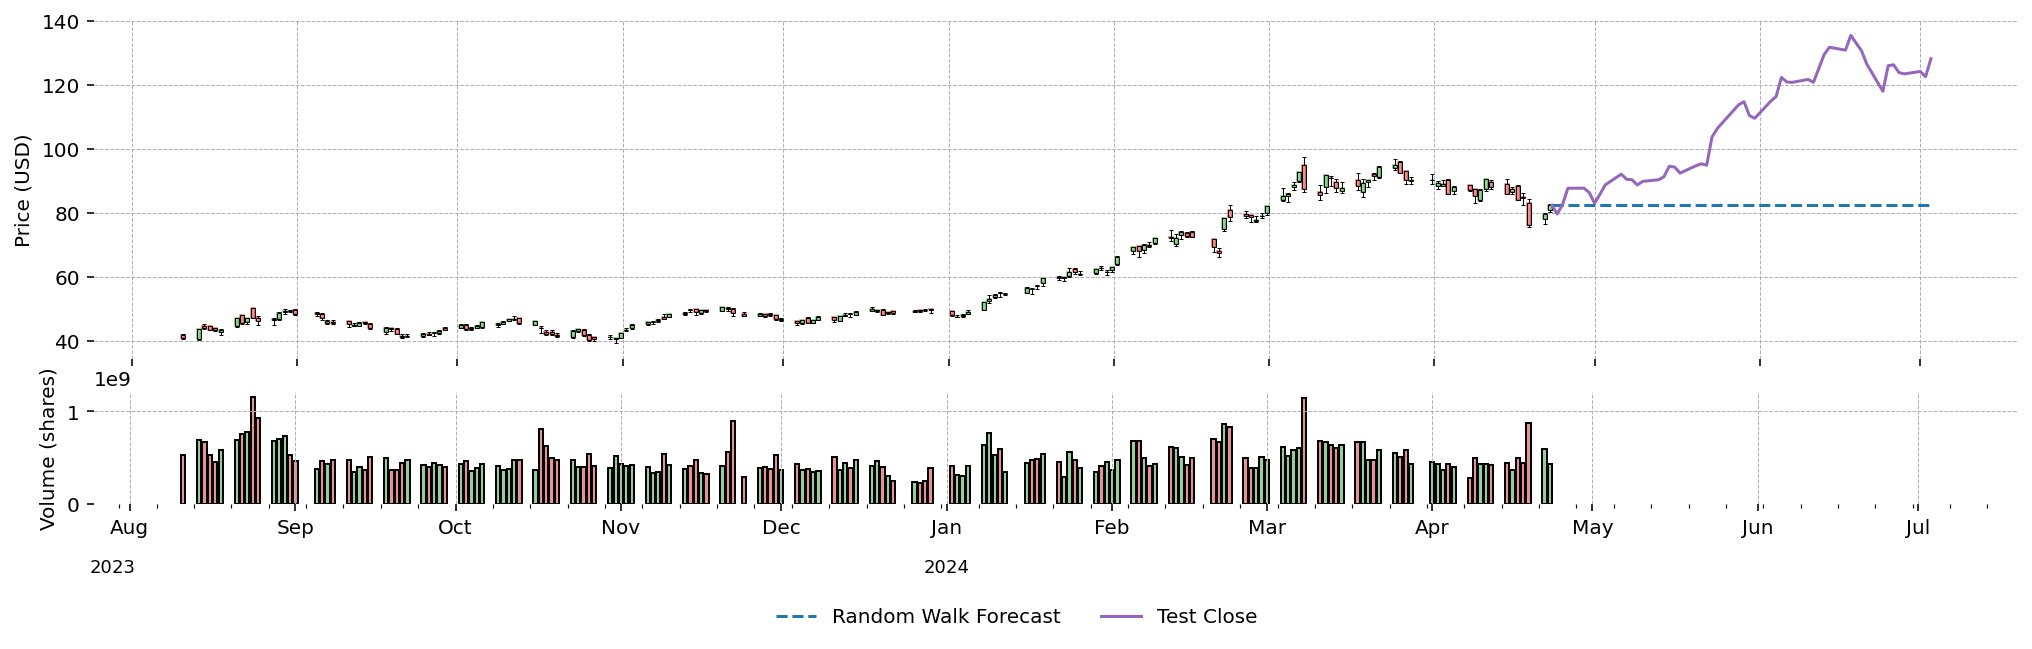

In [13]:
plot_candlesticks_with_forecast(df_train, df_test, draw_rw=True)
plt.show()

This is a pretty good illustration of the strength of the random walk assumption, and of the frustrating difficulty of forecasting. Obviously if we had split the train/test set differently, we would have ended up with something very different. There have been large price movements since the end of training data, notably in July 2023, but the price appears to have come back to the current price.

Why the current price, though? The Efficient Market Hypothesis (EMH) argues that current prices reflect all available information, both public and private, present and past. Thus, the current price is the best you can do -- there's nothing more to learn about from past data.

If this strikes you as a bold claim, you're not alone. I will not blame you for wanting to try to wring out some information from the past. For example, instead of forecasting with the current price, we can forecast with the sample average price. This takes all available information into account, weighting it all equally:

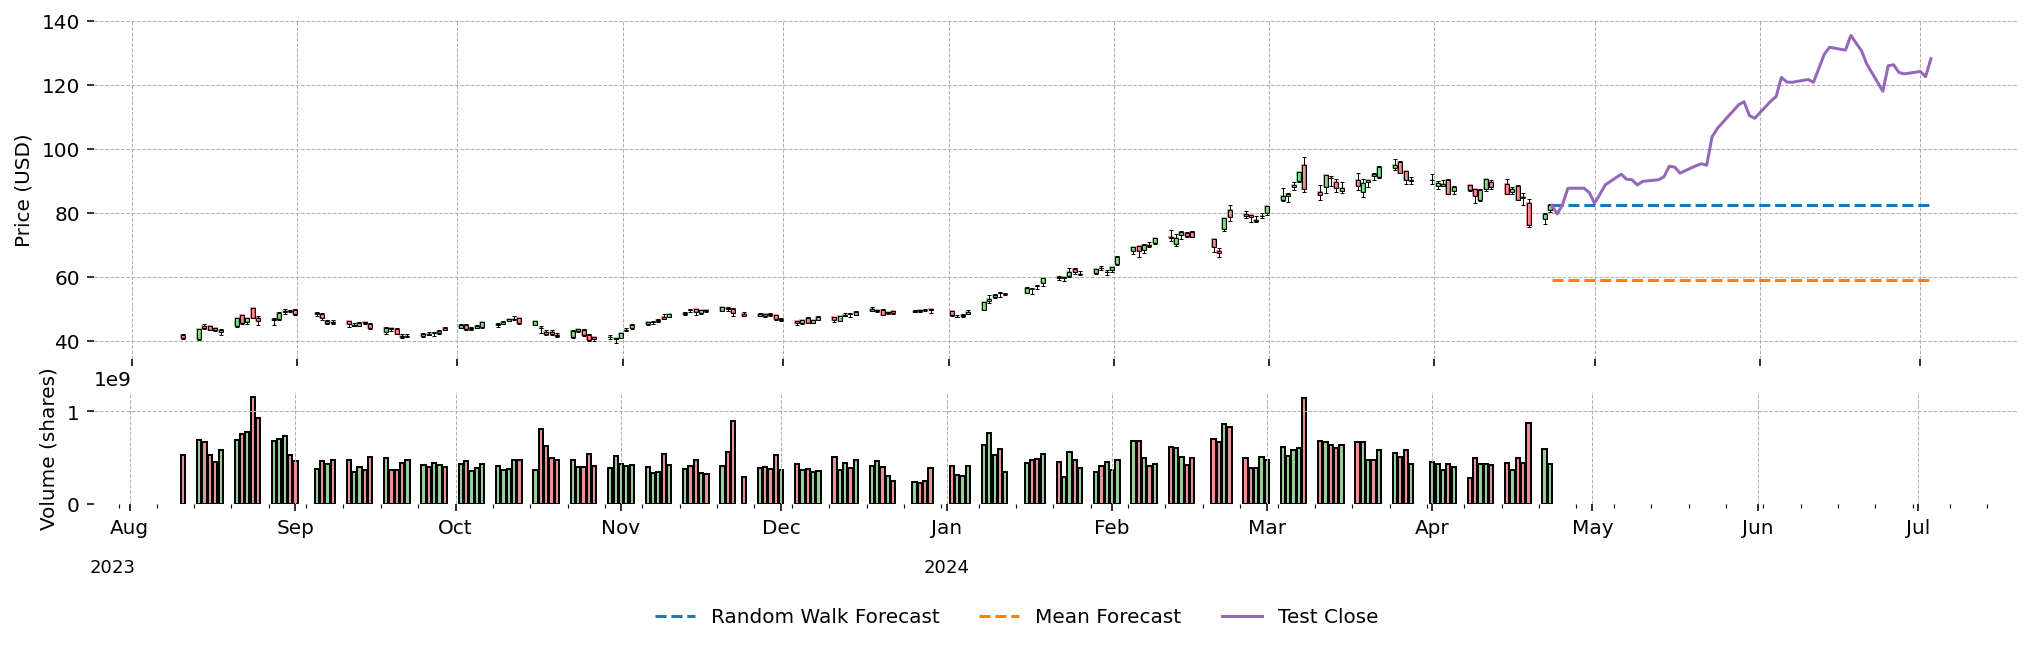

In [14]:
plot_candlesticks_with_forecast(df_train, df_test, draw_rw=True, draw_mean=True)
plt.show()

Why is the average forecast even worse? Intuitively, we might not expect price values from 12 months ago to matter. Data from before the January-March 2024 increase is pulling the average down. Do we really believe that this entire run-up in valuation will be reversed tomorrow? Probably not.

We can view both of these forecasts as weighted functions of the data. Specifically, they are both $P_{t+h} = \sum_{t=0}^T w_t P_t$, where $w = \begin{bmatrix}0 & 0 & \cdots & 0 & 1\end{bmatrix}$ in the random walk case, and $w = \begin{bmatrix} \frac{1}{T} & \frac{1}{T} & \cdots & \frac{1}{T} & \frac{1}{T}\end{bmatrix}$ in the mean case.

What would be better is a weighting scheme that weights recent data more heavily than past data. This is the ETS model. We will choose:

$$
w = \begin{bmatrix} \alpha (1 - \alpha)^{T} & \alpha (1 - \alpha)^{T-1} \cdots & \alpha (1 - \alpha)^2 & \alpha (1 - \alpha) & \alpha \end{bmatrix}
$$

With $\alpha \in (0, 1)$ as a smoothing parameter that tells us how quickly the importance of past data decays as we move through time.

This next plot shows how varying alpha changes the importance of past datapoints in the forecast. When alpha is very small (blue, hiding at the bottom), we're quite close to the mean situation where all datapoints are given equal weight (homework: show that $\lim_{a \to 0} \sum_{t=0}^\infty a(1 - a)^t = 1$, implying uniform weights). When alpha is large, only the recent past matters. At $\alpha=1$, we are in the random walk regime.

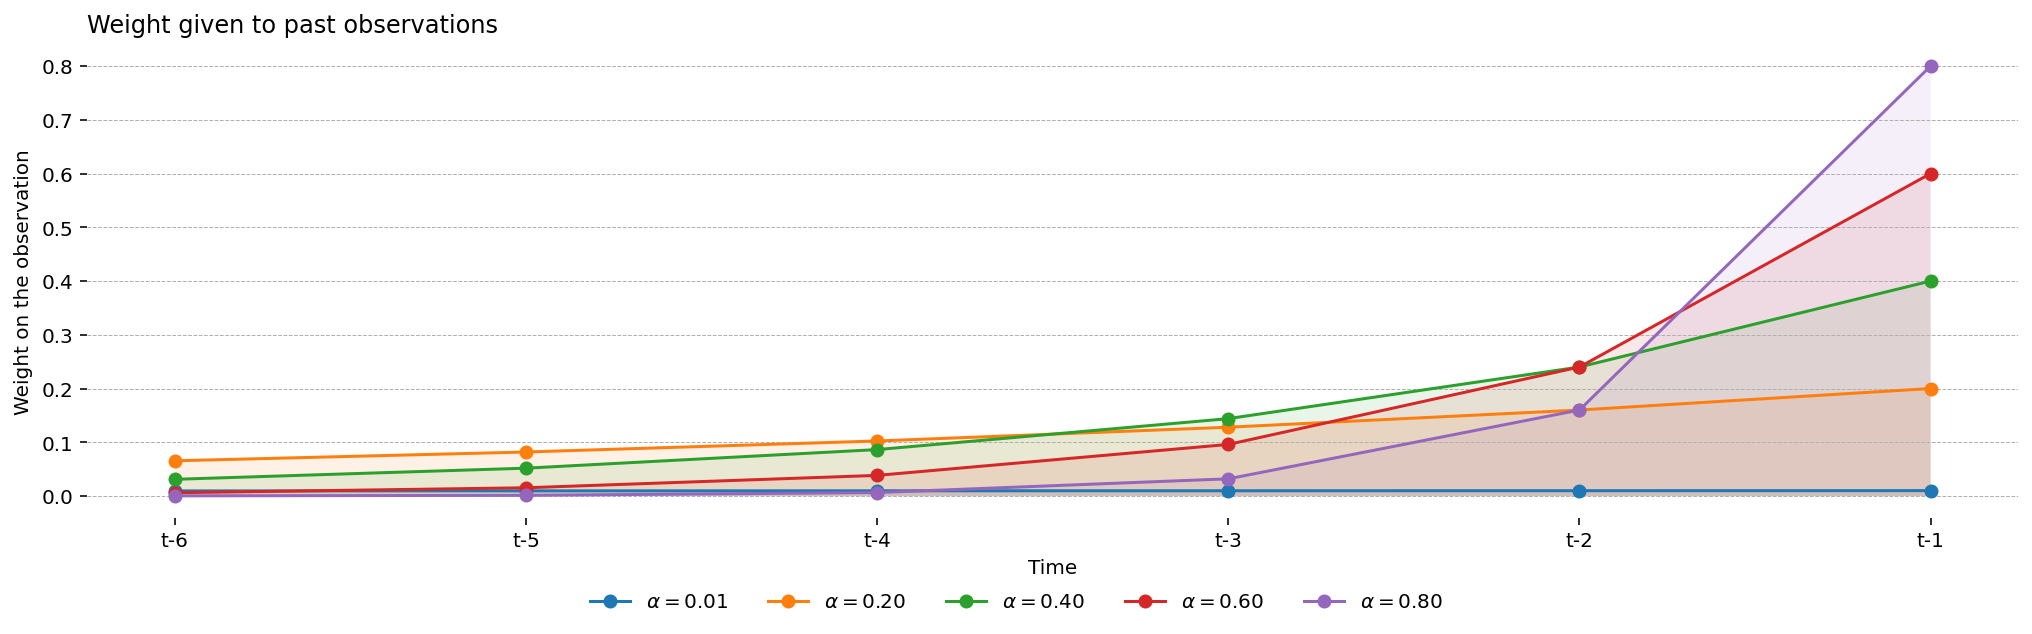

In [15]:
alphas = [0.01, 0.2, 0.4, 0.6, 0.8]
n_lags = 6
time_grid = np.arange(n_lags)

fig, ax = plt.subplots()

for alpha in alphas:
    decay = alpha * (1 - alpha) ** time_grid[::-1]
    ax.fill_between(time_grid, 0, decay, alpha=0.1)
    ax.plot(time_grid, decay, label=rf"$\alpha = {alpha:0.2f}$", marker="o")

ax.set(
    ylabel="Weight on the observation",
    xlabel="Time",
    xticks=time_grid,
    xticklabels=[f"t-{h}" for h in range(n_lags, 0, -1)],
)
ax.set_title("Weight given to past observations", loc="left")
ax.grid(visible=False, axis="x")

handles, labels = ax.get_legend_handles_labels()
fig.legend(
    handles=handles,
    labels=labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.08),
    ncol=len(labels),
    frameon=False,
)
plt.show()

The equation for the weights can be rewritten recursively. Suppose we start with an initial state (call it the "level" of the time series), $\ell_0$. We then observe $P_1$, and want to update our level value to $\ell_1$. This first update will be:

$$ \ell_1 = \alpha P_1 + (1 - \alpha) \ell_0$$

And so on:

$$
\begin{aligned}
\ell_2 &= \alpha P_2 + (1 - \alpha) \ell_1 \\
\ell_3 &= \alpha P_3 + (1 - \alpha) \ell_2 \\
\ell_4 &= \alpha P_4 + (1 - \alpha) \ell_3 \\
& \vdots \\
\ell_t &= \alpha P_t + (1 - \alpha) \ell_{t-1}
\end{aligned}
$$

Repeatedly forward substitute $\ell_2$ into $\ell_3$ and so on to obtain:

$$
\begin{aligned}
\ell_2 &= \alpha P_2 + (1 - \alpha) \alpha P_1 + (1 - \alpha) \ell_0 \\
\ell_3 &= \alpha P_3 + (1 - \alpha) (\alpha P_2 + (1 - \alpha) \alpha P_1 + (1 - \alpha) \ell_0) \\
&= \alpha P_3 + \alpha (1 - \alpha) P_2 + \alpha (1 - \alpha)^2 P_1 + (1 - \alpha) ^2 \ell_0 \\
\ell_4 &= \alpha P_4 + (1 - \alpha) (\alpha P_3 + \alpha (1 - \alpha) P_2 + \alpha (1 - \alpha)^2 P_1 + (1 - \alpha) ^2 \ell_0) \\
&= \alpha P_4 + \alpha (1 - \alpha) P_3 + \alpha (1 - \alpha)^2 P_2 + \alpha (1 - \alpha)^3 P_1 + (1 - \alpha)^3 \ell_0 \\
& \vdots \\
\ell_t &= \sum_{s=0}^t \alpha (1 - \alpha)^s P_{t-s} + (1 - \alpha)^t \ell_0
\end{aligned}
$$

This shows a nice recursive formulation we can use to estimate these models. We keep track of a hidden state, the estimated level $\ell_t$, and we update it each step by taking a weighted average of the new observation $P_t$, and the previous hidden state, $\ell_{t-1}$.

## Statespace Form

Recall that a linear-gaussian statespace is written as:

$$\begin{aligned}
x_t &= Ax_{t-1} + c_t + R\varepsilon_t \\
y_t &= Zx_t + d_t + \eta_t \\
\varepsilon_t &\sim N(0, Q) \\
\eta_t &\sim N(0, H)
\end{aligned}
$$

Taking $\ell_t$ as our $x_t$, we're starting to get quite close to this formulation:

$$
\ell_t = \alpha P_t + (1 - \alpha) \ell_{t-1}
$$

We'd really like to do two things at this stage. First, eliminate $P_t$ from the transition equation, because this should not depend on the observed data, and certainly not on data that is contemporaneous with our hidden states (otherwise what is the use of forecasting!). Second, we'd like some source of stochastic innovations to drive the system.

We can accomplish both of these at once by thinking about the _estimation error_, $P_t - \ell_t$. Do some algebra:

$$
\begin{aligned}
\ell_t &= \alpha P_t + (1 - \alpha) \ell_{t-1} \\
& = \alpha P_t + \ell_{t-1} - \alpha \ell_{t-1} \\
& = \ell_{t-1} + \alpha (P_t - \ell_{t-1} ) \\
&= \ell_{t-1} + \alpha \varepsilon_t
\end{aligned}
$$

Assume our estimation errors, $\varepsilon_t = P_t - \ell_{t-1}$, are normally distributed with variance $\sigma^2$ (other assumptions are possible of course, but this one makes it fit into our setup!).

We can also rearrange this definition to get an update for $P_t$ that depends only on the past level:

$$\begin{aligned}
\varepsilon_t &= P_t - \ell_{t-1} \Rightarrow \\
P_t &= \ell_{t-1} + \varepsilon_t
\end{aligned}
$$

This gets us nicely to a statespace formulation. Define:

$$ x_t = \begin{bmatrix} e_t \\ \ell_t \end{bmatrix}, y_t = \begin{bmatrix} P_t \end{bmatrix},  A = \begin{bmatrix} 0 & 0 \\ 0 & 1 \end{bmatrix}, R = \begin{bmatrix} 1 - \alpha \\ \alpha \end{bmatrix}, Z = \begin{bmatrix} 1 & 1 \end{bmatrix}$$


Starting from the transition equation:

$$\begin{aligned}
x_t &= A x_{t-1} + R \varepsilon_t \\
\begin{bmatrix} e_t \\ \ell_t \end{bmatrix} &= \begin{bmatrix} 0 & 0 \\ 0 & 1 \end{bmatrix} \begin{bmatrix} e_{t-1} \\ \ell_{t-1} \end{bmatrix} + \begin{bmatrix} 1 - \alpha \\ \alpha \end{bmatrix} \varepsilon_t \\
x_t &= \begin{bmatrix} (1 - \alpha) \varepsilon_t \\ \ell_{t-1} + \alpha \varepsilon_t \end{bmatrix}
\end{aligned}
$$

And the observation equation:

$$
\begin{aligned}
y_t &= Zx_t \\
\begin{bmatrix} P_t \end{bmatrix} &= \begin{bmatrix} 1 & 1 \end{bmatrix} \begin{bmatrix} (1 - \alpha) \varepsilon_t \\ \ell_{t-1} + \alpha \varepsilon_t \end{bmatrix} \\
P_t &= (1 - \alpha) \varepsilon_t + \ell_{t-1} + \alpha \varepsilon_t  \\
&= \ell_{t-1} + \varepsilon_t
\end{aligned}
$$

Notice that we introduced an auxiliary state, $e_t$, to carry the scaled innovations $(1 - \alpha)\varepsilon_t$, into the observation equation. Looking at the equation $P_t = \ell_{t-1} + \varepsilon_t$, you might be tempted to conclude that $\varepsilon_t$ is measurement noise, but it isn't!

### Effect of varying $\alpha$, $\sigma$, and $\ell_0$

The following code sets up an interactive widget that allows you to see the effect of varying the three parameters of the ETS model, $\alpha$, $\sigma$, and $\ell_0$, on both the in-sample fit and a 30-day forecast.

In [16]:
demo_mod = pmss.BayesianETS(endog_names=["Close"], order=("A", "N", "N"), verbose=False)

Play with these sliders to get the following take-aways:

1. Sliding $\alpha$ interpolates between the uniform forecast (the red line) and the random walk forecast (the green line).
2. Despite this, the forecasts are not bound between the two values. If you choose $\alpha = 0.4$ for example, it will give more weight to the higher values before the dip in the last observation, and the prediction ends up being higher than the random walk prediction.
3. The initial level, $\ell_0$ (that is, the price at time 0, before we observe data), doesn't matter at all to the forecasts. Even if you pick something crazy, it will be washed away by data.
4. Increasing $\sigma$ somewhat smoothes the time series, but not to the same degree as scaling down $\alpha$.
5. There is an interaction effect between $\alpha$ and $\sigma$!
6. No matter what, you will always get constant predictions with this model.

In [17]:
display(make_interactive_plot(demo_mod, df_train))

interactive(children=(FloatSlider(value=0.99, description='Alpha:', max=0.999999, min=1e-06, step=0.01), Float…

### Bayesian Estimation

To choose values for these parameters, we want to of course estimate the joint posterior. This is done by creating a `BayesianETS` model. Like ARIMA models, ETS models are described with a 3-tuple called the "order" of the model. Unlike ARIMA, the 3-tuple of an ETS model is written with three _strings_: `(error_type, trend_type, season_type)`

- In the literature, `error_type` is either `A` for "Additive" or `M` for "Multiplicative". Here, we can only pick "Additive" (since we're doing a linear model!). But you can get the multiplicative model if you model the log of your data, then reverse-transform the forecasts.
- `trend_type` is either `N` for "No trend", `A` for "Additive trend", or `Ad` for "Additive trend with dampening". For the simple model we are currently studying, we choose `N`.
- `seasonal_type` is either `N` for "No seasonality" or `A` for "Additive seasonality". Again, our current model takes `N`.

In [18]:
ss_mod = pmss.BayesianETS(
    endog_names=["Close"],
    order=("A", "N", "N"),
)

                  Model Requirements                  
                                                      
  Variable        Shape   Constraints     Dimensions  
 ──────────────────────────────────────────────────── 
  initial_level   ()                            None  
  alpha           ()      0 < alpha < 1         None  
  sigma_state     ()      Positive              None  
                                                      
 These parameters should be assigned priors inside a  
         PyMC model block before calling the          
            build_statespace_graph method.            

In [19]:
with pm.Model(coords=ss_mod.coords) as level_mod:
    initial_level = pm.Normal("initial_level", mu=df_train.Close.values[0], sigma=10)

    # Bias alpha upwardly -- we don't believe the mean of the data will be the forecast!
    alpha = pm.Beta("alpha", alpha=3, beta=1)
    sigma_state = pm.Exponential("sigma_state", lam=1)

    ss_mod.build_statespace_graph(data=df_train.Close)

    idata = pm.sample(**SAMPLER_KWARGS)

/Users/jessegrabowski/Documents/Python/pymc_extras/pymc_extras/statespace/utils/data_tools.py:210: ImputationWarning: Provided data contains missing values and will be automatically imputed as hidden states during Kalman filtering.
  warnings.warn(impute_message, ImputationWarning)


NUTS[nutpie]: [initial_level, alpha, sigma_state]


Output()

In [20]:
idata_post = ss_mod.sample_conditional_posterior(idata)
forecast = ss_mod.forecast(idata, start=df_train.index[-1], end=df_test.index[-1])

Sampling: [filtered_posterior, filtered_posterior_observed, predicted_posterior, predicted_posterior_observed, smoothed_posterior, smoothed_posterior_observed]


Output()

Sampling: [forecast_combined]


Output()

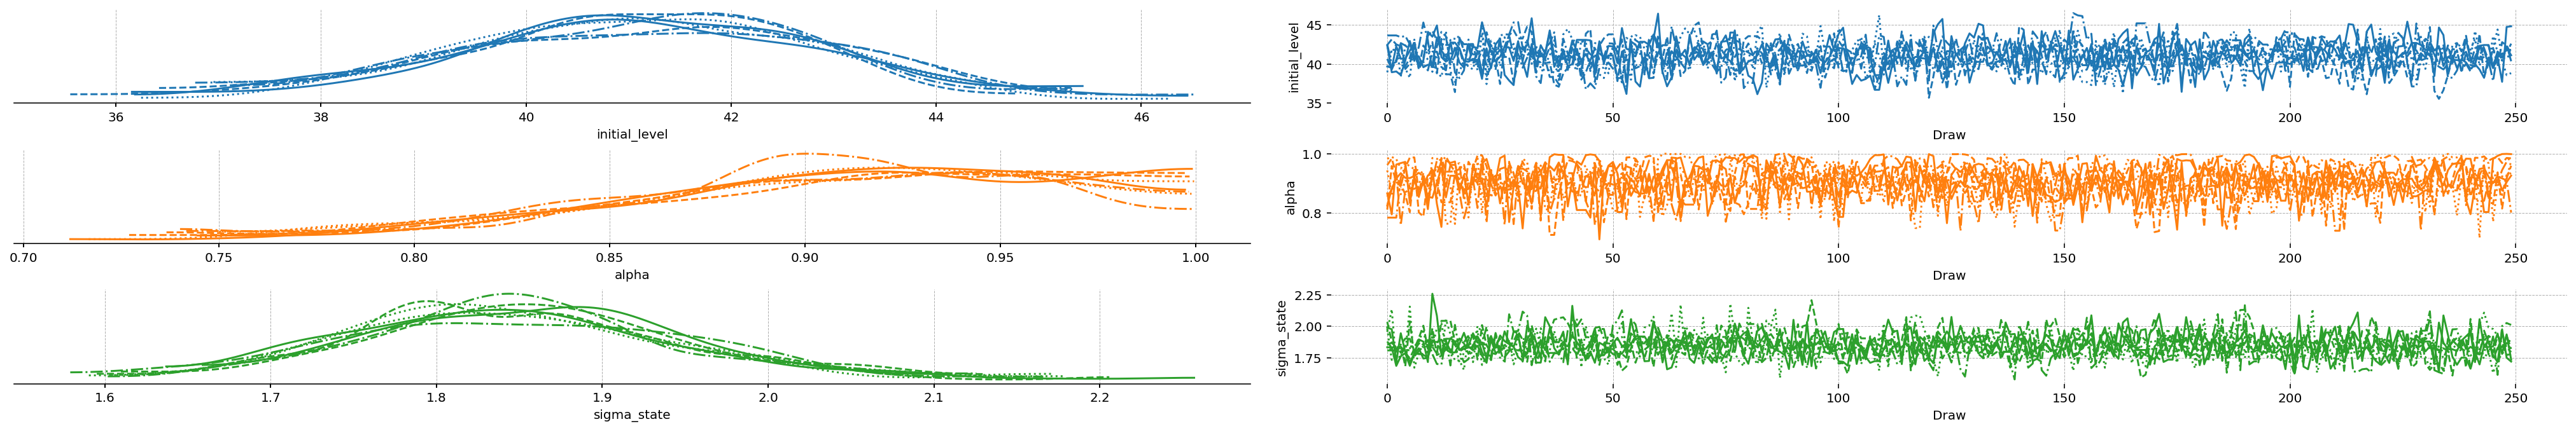

In [21]:
az.plot_trace_dist(idata, var_names=[x.name for x in level_mod.free_RVs])
plt.show()

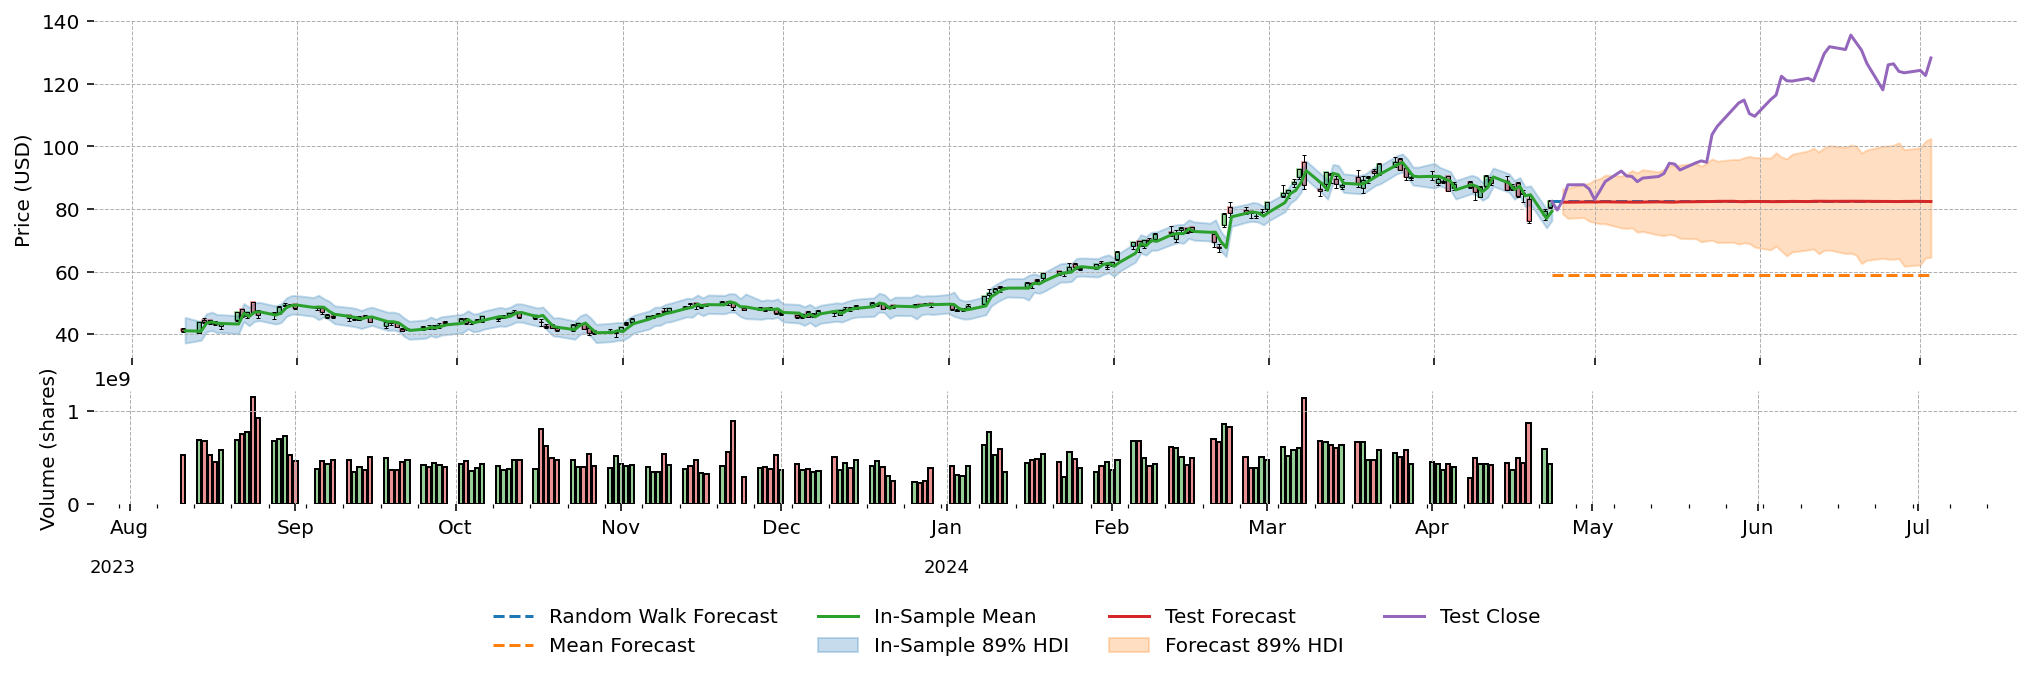

In [22]:
plot_candlesticks_with_forecast(
    df_train,
    df_test,
    idata=idata_post,
    idata_forecast=forecast,
    draw_rw=True,
    draw_mean=True,
)
plt.show()

## Adding a Trend

As alluded to in the presentation of the `order` argument, ETS models can accommodate a trend and seasonal component. For details about how the model develops in those cases, the reader is referred to Forecasting: Principles and Practice, [Chapter 8.2](https://otexts.com/fpp3/holt.html) and [Chapter 8.3](https://otexts.com/fpp3/holt-winters.html), respectively. Here we present just a quick summary.

When we add a trend, we extend the model to estimate a local slope at each timestep. Like the level, the slope is a weighted average of:

1. An estimated hidden state, $b_t$, and;
2. The change in the level at time $t$, $\ell_t - \ell_{t-1}$

The hidden state at time $t$ is thus:

$$
b_t = \beta^\star (\ell_t - \ell_{t-1}) + (1 - \beta^\star) b_{t-1}
$$

With $\beta^\star \in (0, 1)$. The $\star$ is used to distinguish between two parameterizations. If you do the same algebraic gymnastics as above, you will find the following statespace:

$$
\begin{aligned}
y_t&=\ell_{t-1}+b_{t-1}+\varepsilon_t\\
\ell_t&=\ell_{t-1}+b_{t-1}+\alpha \varepsilon_t\\
b_t&=b_{t-1}+ \alpha \beta^\star \varepsilon_t
\end{aligned}
$$

How the statespace matrices look in this case is left as an exercise to the reader.

Note that the level and trend weights, $\alpha$ and $\beta^\star$, are multiplied together in the trend update equation. This is why an alternative parameterization exists. The `fable` R package, as well as the `statsmodels` trend smoothing implementation, use $\beta = \alpha \beta^\star$. As a result, $\alpha$ is first estimated, then $\beta$ is estimated such that $0 < \beta < \alpha$ (dividing through by $\alpha$ gives $0 < \beta^\star < 1$).

By default, `BayesianETS` gives you the "star" parameterization, so you can set priors for $\beta^\star$ on the unit interval. If you want the other one, you can request `use_transformed_parameterization = True`, but be aware you're responsible for making sure $0 < \beta < \alpha$ is respected.

### Interactive Graph

Playing with this graph, you will find that unlike in a model with a trend *parameter*, like a slope-intercept model, the value of $\beta$ is not obviously connected to the slope of the forecasts. When $\beta$ is large, the forecasts are negative, because a large $\beta$ puts more weight on the most recent level shifts. Since the very end of the data is a downtick, this will render the forecast negative.

When $\beta$ is very small, on the other hand, the level shifts in the data are given more equal weight. Since the overall trend in the data is positive, this results in a positive slope in the forecast.

On the lower plot, you can also see the first differences of the data. When $\alpha = 1$ and $\beta = 1$, the trend component will be equal to the first differences. The dynamics of $\beta$ are exactly the same as those of $\alpha$. When $\beta = 0$, we get the average difference across all the data. When $\beta = 1$, only the last difference is used.

In actuality, the trend component is based on the differences of the estimated level component $\ell_t - \ell_{t-1}$, rather than the data. So this analysis is mediated through the $\alpha$ parameter. As $\alpha$ decreases, we consider differences in the resulting smoothed trend, rather than the data itself.

In [23]:
demo_trend_mod = pmss.BayesianETS(endog_names=["Close"], order=("A", "Ad", "N"), verbose=False)
display(make_interactive_plot(demo_trend_mod, df_train, include_trend=True, draw_lines=False))

interactive(children=(FloatSlider(value=0.99, description='Alpha:', max=0.999999, min=1e-06, step=0.01), Float…

### Fit the Model

In [24]:
ss_trend_mod = pmss.BayesianETS(
    endog_names=["Close"],
    order=("A", "A", "N"),
)

                  Model Requirements                  
                                                      
  Variable        Shape   Constraints     Dimensions  
 ──────────────────────────────────────────────────── 
  initial_level   ()                            None  
  initial_trend   ()                            None  
  alpha           ()      0 < alpha < 1         None  
  beta            ()      0 < beta < 1          None  
  sigma_state     ()      Positive              None  
                                                      
 These parameters should be assigned priors inside a  
         PyMC model block before calling the          
            build_statespace_graph method.            

In [25]:
with pm.Model(coords=ss_trend_mod.coords) as trend_mod:
    initial_level = pm.Normal("initial_level", mu=df_train.Close.values[0], sigma=10)
    initial_trend = pm.Normal("initial_trend", mu=0, sigma=3)

    alpha = pm.Beta("alpha", alpha=3, beta=1)
    beta = pm.Beta("beta", alpha=1, beta=1)

    sigma_state = pm.Exponential("sigma_state", lam=1)

    ss_trend_mod.build_statespace_graph(data=df_train.Close)

    idata_trend = pm.sample(**SAMPLER_KWARGS)

/Users/jessegrabowski/Documents/Python/pymc_extras/pymc_extras/statespace/utils/data_tools.py:210: ImputationWarning: Provided data contains missing values and will be automatically imputed as hidden states during Kalman filtering.
  warnings.warn(impute_message, ImputationWarning)


NUTS[nutpie]: [initial_level, initial_trend, alpha, beta, sigma_state]


Output()

In [26]:
idata_trend_post = ss_trend_mod.sample_conditional_posterior(idata_trend)
idata_trend_forecast = ss_trend_mod.forecast(
    idata_trend, start=df_train.index[-1], end=df_test.index[-1]
)

Sampling: [filtered_posterior, filtered_posterior_observed, predicted_posterior, predicted_posterior_observed, smoothed_posterior, smoothed_posterior_observed]


Output()

Sampling: [forecast_combined]


Output()

In [27]:
az.summary(idata_trend, var_names=[x.name for x in trend_mod.free_RVs])

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
initial_level,41.25,1.89,38,44,1571,1212,1.00,0.048,0.035
initial_trend,0.25,0.5,-0.56,1.1,1288,1091,1.01,0.014,0.011
alpha,0.872,0.073,0.75,0.98,864,760,1.01,0.0023,0.0015
beta,0.049,0.034,0.0043,0.11,525,336,1.02,0.0012,0.00091
sigma_state,1.862,0.104,1.7,2,1597,1273,1.01,0.0026,0.0019


Adding a trend makes the out-of-sample fit much worse. It extrapolates the trend forever in an extremely optimistic fashion. The estimated $\beta$ is small -- between 0.0 and 0.08 -- but the trend it implies still compounds over the whole forecast horizon.

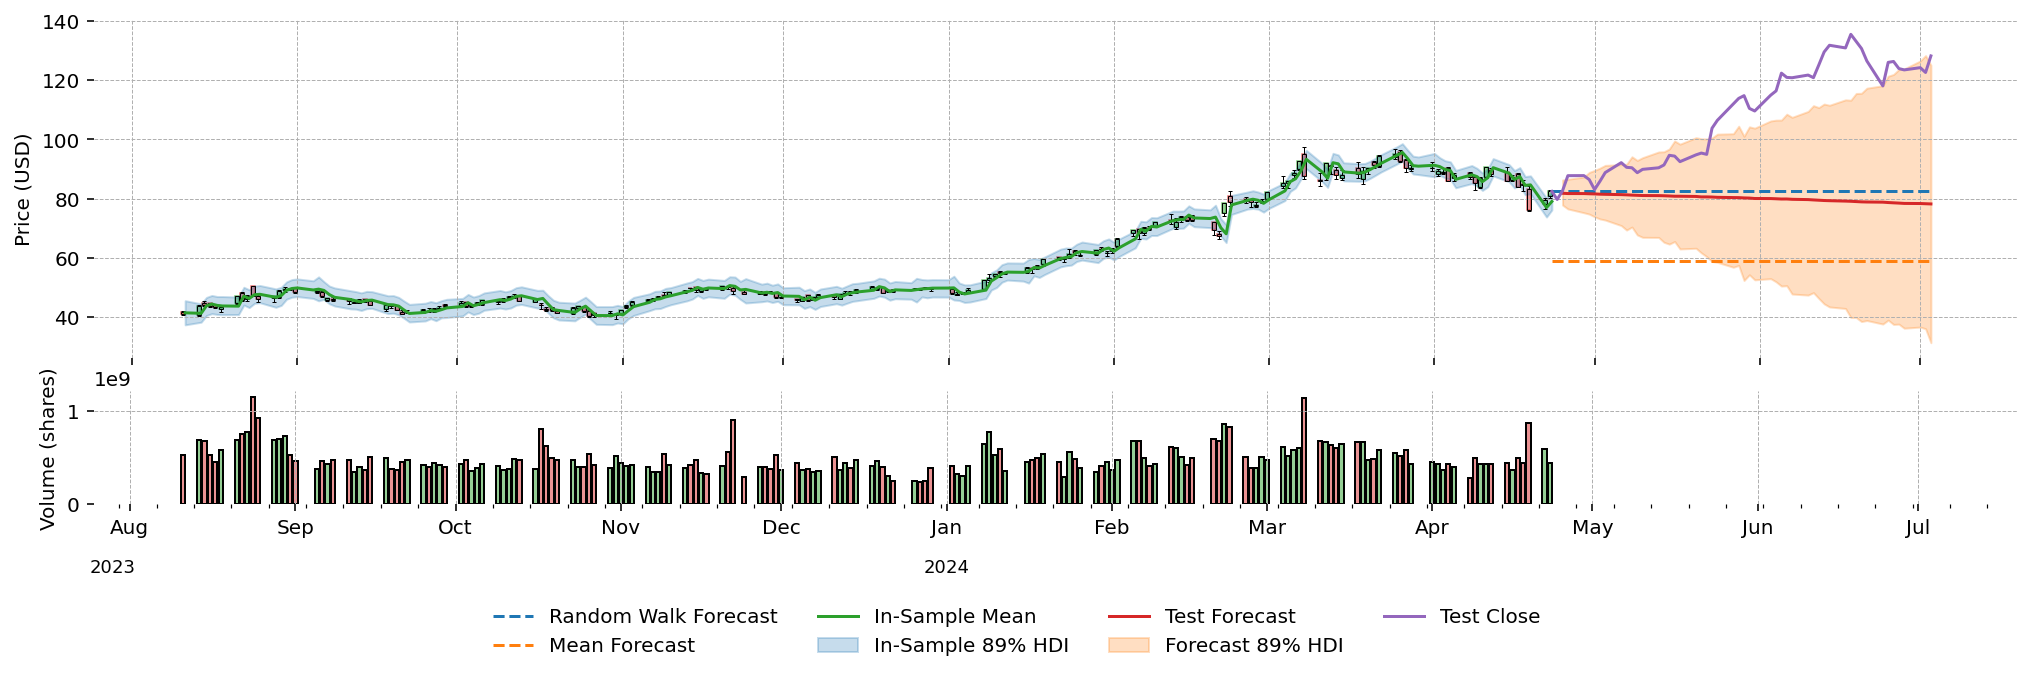

In [28]:
plot_candlesticks_with_forecast(
    df_train,
    df_test,
    idata=idata_trend_post,
    idata_forecast=idata_trend_forecast,
    draw_rw=True,
    draw_mean=True,
)
plt.show()

#### Decomposition

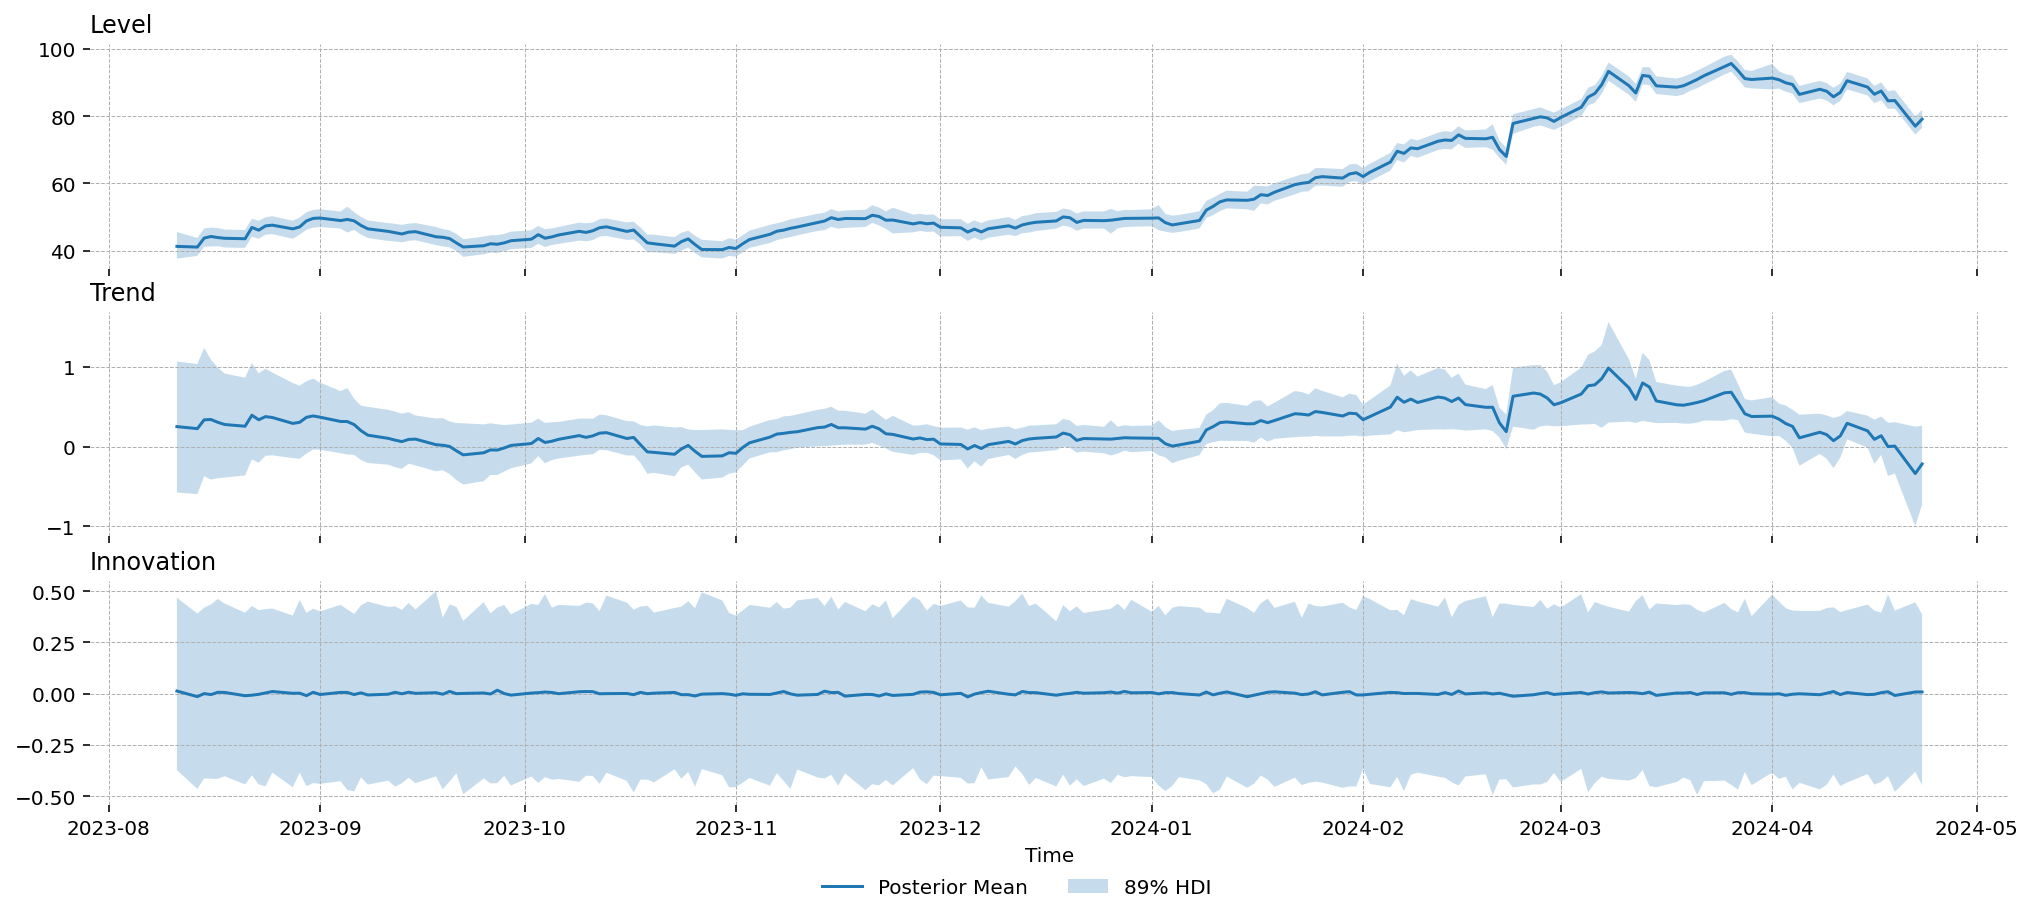

In [29]:
plot_decomposition(
    idata_trend_post.predicted_posterior,
    state_names=["level", "trend", "innovation"],
    n_rows=3,
    n_cols=1,
)
plt.show()

#### Damped Trend

One way to "fix" these overly optimistic trends is to add a dampening term. This will force the trend to slow down over time, making forecasts slowly return to a long-run mean. To ask for a damped trend, use `Ad` order for the trend.

By the way, if you don't care for this `order` business, you can instead build the model using a series of boolean arguments. This is demonstrated below.

We now need to give a prior for `phi`, which is the degree of dampening on the trend term. [FPP3 gives guidance](https://otexts.com/fpp3/holt.html#damped-trend-methods) on choosing priors for $\phi$:

> In practice, $\phi$ is rarely less than 0.8 as the damping has a very strong effect for smaller values. Values of $\phi$ close to 1 will mean that a damped model is not able to be distinguished from a non-damped model. For these reasons, we usually restrict $\phi$ to a minimum of 0.8 and a maximum of 0.98.

In the interactive graph, try setting $\beta$ to be large and small, and see how varying $\phi$ interacts in both of these regimes. You should find that for large beta, having a dampening term on the trend causes a "bend" back to a long term mean. If beta is too small, however, having even $\phi = 0.99$ essentially erases the trend.

In [30]:
display(
    make_interactive_plot(
        mod=demo_trend_mod,
        df_train=df_train,
        include_trend=True,
        include_phi=True,
        draw_lines=False,
    )
)

interactive(children=(FloatSlider(value=0.99, description='Alpha:', max=0.999999, min=1e-06, step=0.01), Float…

#### Putting a prior on the initial state covariance

Every model so far has accepted the default `stationary_initialization=True`. An ETS model has a single source of error, so once the initial states are given the data pin down every later state exactly. The initial state covariance `P0` is therefore fixed at $R Q R^T$, the covariance of the first innovation, and no prior on it is needed. This is the textbook ETS setup, and it also lets `BayesianETS` evaluate the likelihood through the ETS error recursion instead of a Kalman filter, which is much faster. The recursion needs complete data, though. The stock series has gaps on weekends and holidays, so every model on it is filtered anyway; only the airline passenger model at the end of this notebook takes the fast path.

If you would rather express uncertainty about the initial states through a covariance matrix, pass `stationary_initialization=False`. The model then asks for a `P0` prior, and the likelihood goes through the Kalman filter. We do that once here, for the damped trend model, to show the shape of the prior. The results below are not meaningfully different from what the default would give.

In [31]:
# Equivalent to order = ("A", "Ad", "N")
ss_mod_damped = pmss.BayesianETS(
    endog_names=["Close"],
    trend=True,
    damped_trend=True,
    stationary_initialization=False,
)

                             Model Requirements                             
                                                                            
  Variable        Shape    Constraints                          Dimensions  
 ────────────────────────────────────────────────────────────────────────── 
  initial_level   ()                                                  None  
  initial_trend   ()                                                  None  
  P0              (3, 3)   Positive Semi-definite   ('state', 'state_aux')  
  alpha           ()       0 < alpha < 1                              None  
  beta            ()       0 < beta < 1                               None  
  phi             ()       0 < phi < 1                                None  
  sigma_state     ()       Positive                                   None  
                                                                            
These parameters should be assigned priors inside a PyMC model block before 
                 calling the build_statespace_graph method.                 

In [32]:
with pm.Model(coords=ss_mod_damped.coords) as damped_trend_mod:
    initial_level = pm.Normal("initial_level", mu=df_train.Close.values[0], sigma=10)
    initial_trend = pm.Normal("initial_trend", mu=0, sigma=3)
    P0_diag = pm.Gamma("P0_diag", alpha=2, beta=1, dims=["state"])
    P0 = pm.Deterministic("P0", pt.diag(P0_diag), dims=["state", "state_aux"])

    alpha = pm.Beta("alpha", alpha=3, beta=1)
    beta = pm.Beta("beta", alpha=1, beta=3)

    phi_params = pz.maxent(pz.Beta(), lower=0.8, upper=0.98, plot=False).params_dict
    phi = pm.Beta("phi", **phi_params)

    sigma_state = pm.Exponential("sigma_state", lam=1)

    ss_mod_damped.build_statespace_graph(data=df_train.Close)

    idata_damped_trend = pm.sample(**SAMPLER_KWARGS)

/Users/jessegrabowski/Documents/Python/pymc_extras/pymc_extras/statespace/utils/data_tools.py:210: ImputationWarning: Provided data contains missing values and will be automatically imputed as hidden states during Kalman filtering.
  warnings.warn(impute_message, ImputationWarning)


NUTS[nutpie]: [initial_level, initial_trend, P0_diag, alpha, beta, phi, sigma_state]


Output()

In [33]:
idata_damped_post = ss_mod_damped.sample_conditional_posterior(idata_damped_trend)
idata_damped_forecast = ss_mod_damped.forecast(
    idata_damped_trend, start=df_train.index[-1], end=df_test.index[-1]
)

Sampling: [filtered_posterior, filtered_posterior_observed, predicted_posterior, predicted_posterior_observed, smoothed_posterior, smoothed_posterior_observed]


Output()

Sampling: [forecast_combined]


Output()

In [34]:
az.summary(idata_damped_trend, var_names=[x.name for x in damped_trend_mod.free_RVs])

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
initial_level,41.55,1.87,39,45,2358,1442,1.01,0.039,0.034
initial_trend,0.72,1.53,-1.6,3.3,2552,1330,1.00,0.03,0.023
P0_diag[innovation],1.99,1.38,0.4,4.6,2301,1105,1.00,0.028,0.033
P0_diag[level],2.02,1.46,0.37,4.7,1939,1225,1.00,0.031,0.036
P0_diag[trend],1.92,1.37,0.35,4.4,2255,1131,1.00,0.027,0.03
alpha,0.859,0.078,0.72,0.97,1478,995,1.00,0.0018,0.0012
beta,0.062,0.044,0.0084,0.14,1666,1105,1.00,0.001,0.00096
phi,0.875,0.065,0.76,0.96,2881,1501,1.01,0.0012,0.00098
sigma_state,1.848,0.102,1.7,2,3202,1636,1.00,0.0018,0.0013


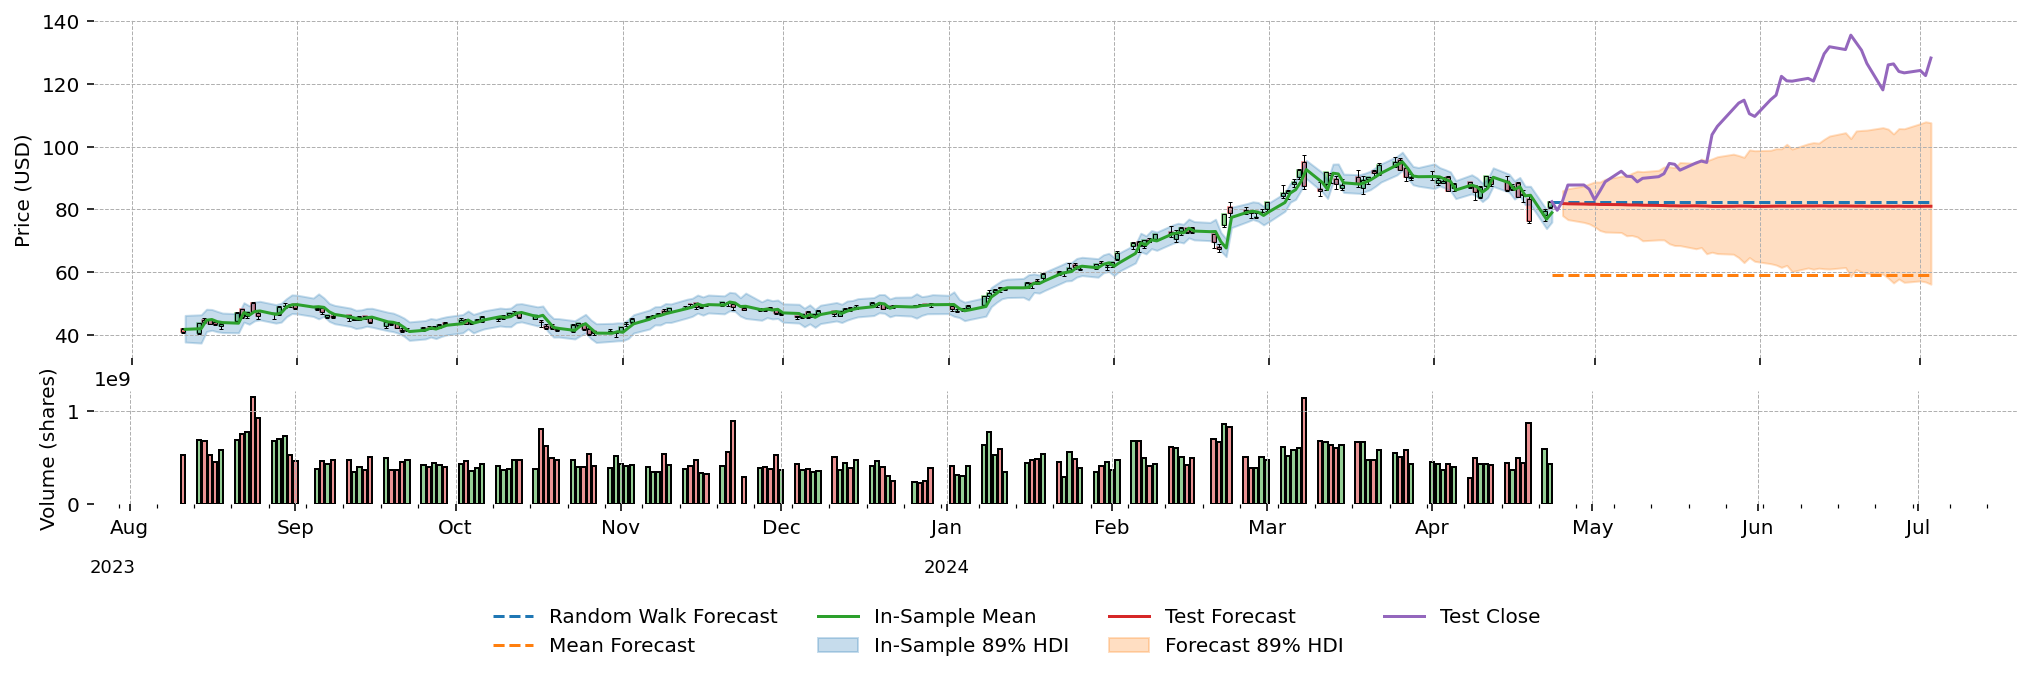

In [35]:
plot_candlesticks_with_forecast(
    df_train,
    df_test,
    idata=idata_damped_post,
    idata_forecast=idata_damped_forecast,
    draw_rw=True,
    draw_mean=True,
)
plt.show()

#### Decomposition

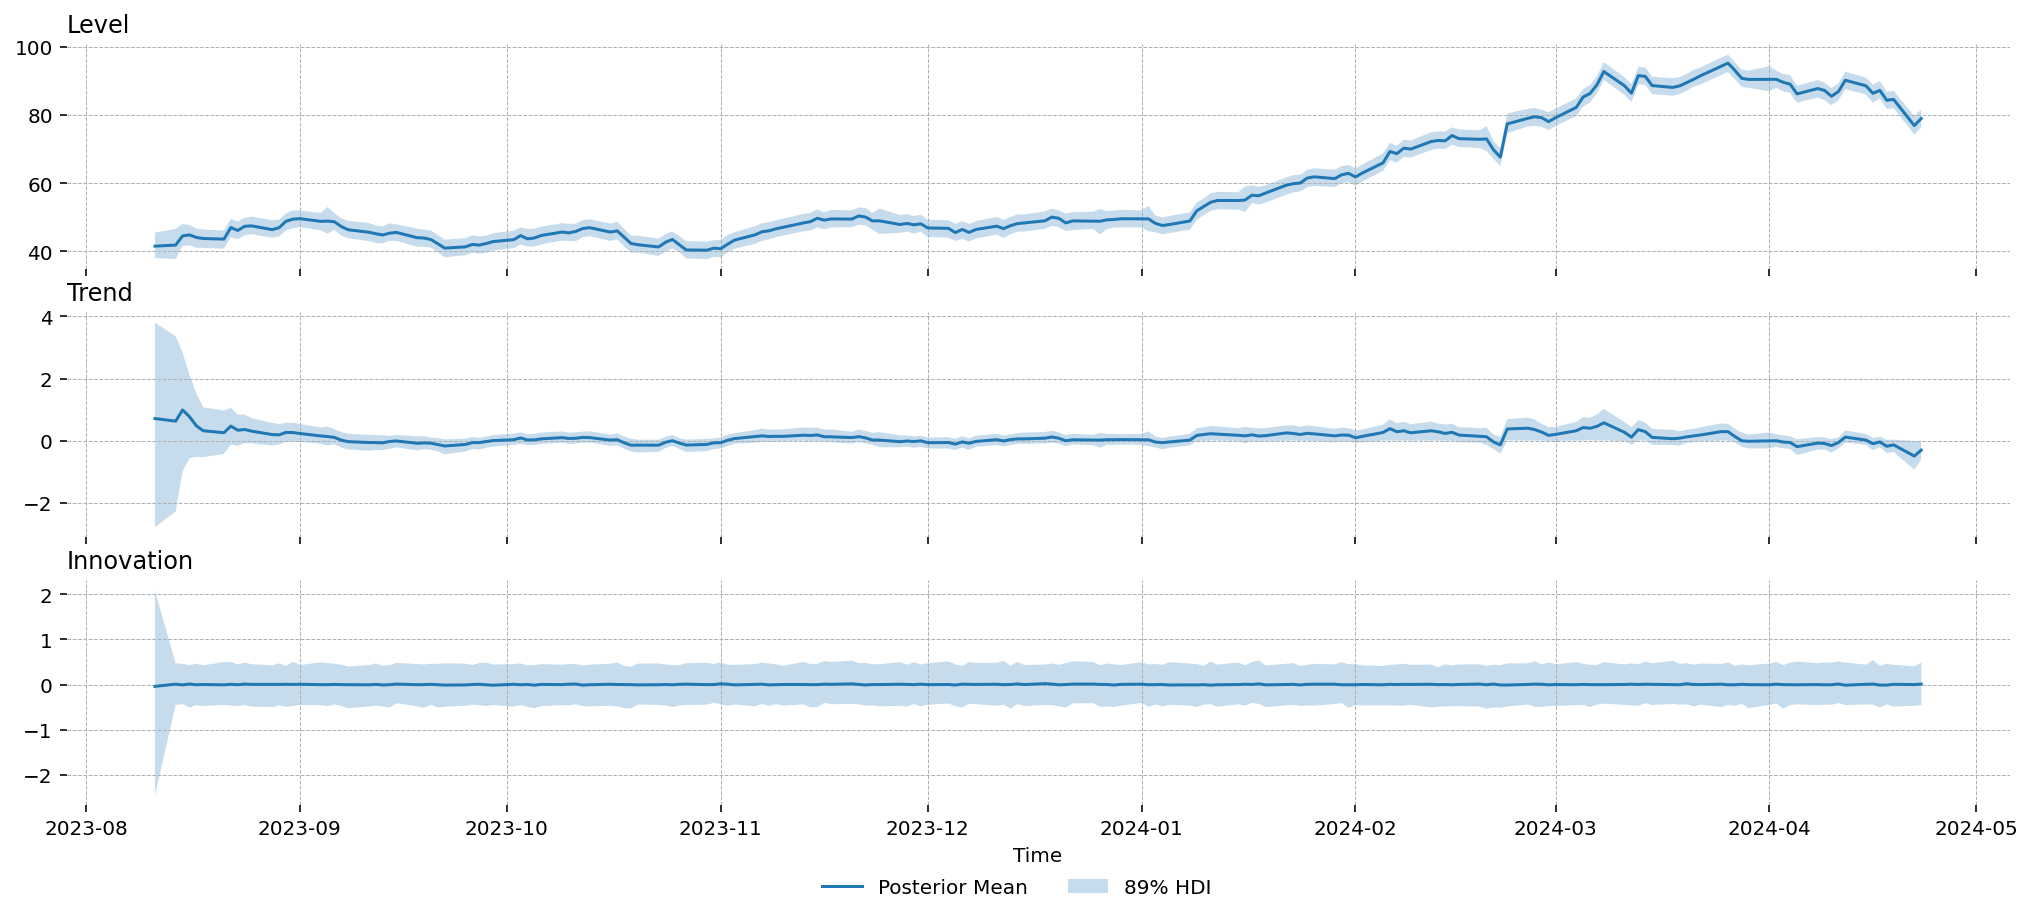

In [36]:
plot_decomposition(
    idata_damped_post.predicted_posterior,
    state_names=["level", "trend", "innovation"],
    n_rows=3,
    n_cols=1,
)
plt.show()

## Joint Estimation of Correlated Time Series

One feature that `BayesianETS` has that statsmodels does not is support for multiple time series.

By using the `endog_names` argument, you can jointly estimate multiple ETS series at the same time. Currently you are restricted to the same ETS family (as specified by the `order`) for each time series, and each time series will have its own $\alpha, \beta, \gamma, \phi$ parameters -- although these can be correlated (or even re-used!) by setting priors.

What is nice, though, is that you can estimate a dense covariance for the innovations on each time series. To do this, we ask for `dense_innovation_covariance=True`. If we set this to `False`, we estimate a diagonal covariance matrix.

We demonstrate this functionality by simultaneously estimating the closing price and the trading volume for \$NVDA.

In [37]:
ss_mod_joint = pmss.BayesianETS(
    endog_names=["Close", "Volume"],
    order=("A", "Ad", "N"),
    dense_innovation_covariance=True,
)

                                      Model Requirements                                      
                                                                                              
  Variable        Shape    Constraints                                            Dimensions  
 ──────────────────────────────────────────────────────────────────────────────────────────── 
  initial_level   (2,)                                                   ('observed_state',)  
  initial_trend   (2,)                                                   ('observed_state',)  
  alpha           (2,)     0 < alpha < 1                                 ('observed_state',)  
  beta            (2,)     0 < beta < 1                                  ('observed_state',)  
  phi             (2,)     0 < phi < 1                                   ('observed_state',)  
  state_cov       (2, 2)   Positive Semi-definite   ('observed_state', 'observed_state_aux')  
                                                                                              
   These parameters should be assigned priors inside a PyMC model block before calling the    
                                build_statespace_graph method.                                

Notice that the required shapes have changed. We now need to give `observed_state` to all the structural parameters, implying that we need one for each sub-model (Close and Volume).

It's good to check the coords to see how the model expects things passed in:

In [38]:
ss_mod_joint.observed_states

('Close', 'Volume')

In [39]:
ss_mod_joint.state_names

('Close_innovation',
 'Close_level',
 'Close_trend',
 'Volume_innovation',
 'Volume_level',
 'Volume_trend')

In [40]:
# Modelling log volume is equivalent to a fully multiplicative model, order (M, Md, N). It also
# keeps the sampler away from the raw share counts, which run into the billions.
df_scaled = df_train[["Close", "Volume"]].assign(Volume=lambda x: np.log(x.Volume))

In [41]:
with pm.Model(coords=ss_mod_joint.coords) as joint_mod:
    initial_level = pm.Normal("initial_level", mu=0, sigma=10, dims=["observed_state"])
    initial_trend = pm.Normal("initial_trend", mu=0, sigma=10, dims=["observed_state"])

    alpha = pm.Beta("alpha", alpha=3, beta=1, dims=["observed_state"])
    beta = pm.Beta("beta", alpha=1, beta=5, dims=["observed_state"])

    phi_params = pz.maxent(pz.Beta(), lower=0.8, upper=0.98, plot=False).params_dict
    phi = pm.Beta("phi", **phi_params, dims=["observed_state"])

    sd_dist = pm.Gamma.dist(alpha=2, beta=[1, 1 / 10])
    chol, *_ = pm.LKJCholeskyCov("state_chol", eta=1, n=2, sd_dist=sd_dist)
    state_cov = pm.Deterministic(
        "state_cov", chol @ chol.T, dims=["observed_state", "observed_state_aux"]
    )

    ss_mod_joint.build_statespace_graph(data=df_scaled)

    idata_joint = pm.sample(**SAMPLER_KWARGS)

/Users/jessegrabowski/Documents/Python/pymc_extras/pymc_extras/statespace/utils/data_tools.py:210: ImputationWarning: Provided data contains missing values and will be automatically imputed as hidden states during Kalman filtering.
  warnings.warn(impute_message, ImputationWarning)


NUTS[nutpie]: [initial_level, initial_trend, alpha, beta, phi, state_chol]


Output()

In [42]:
idata_joint_post = ss_mod_joint.sample_conditional_posterior(idata_joint)
idata_joint_forecast = ss_mod_joint.forecast(
    idata_joint, start=df_train.index[-1], end=df_test.index[-1]
)

Sampling: [filtered_posterior, filtered_posterior_observed, predicted_posterior, predicted_posterior_observed, smoothed_posterior, smoothed_posterior_observed]


Output()

Sampling: [forecast_combined]


Output()

In [43]:
az.summary(
    idata_joint,
    var_names=[
        "initial_level",
        "initial_trend",
        "alpha",
        "beta",
        "phi",
        "state_chol_stds",
        "state_chol_corr",
    ],
    coords={"state_chol_corr_dim_0": [0], "state_chol_corr_dim_1": [1]},
)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
initial_level[Close],39.7,1.86,37,43,3464,1686,1.00,0.032,0.022
initial_level[Volume],20.178,0.215,20,21,2911,1613,1.00,0.004,0.0028
initial_trend[Close],1.18,1.22,-0.51,3.3,1811,1147,1.00,0.03,0.025
initial_trend[Volume],0.021,0.105,-0.14,0.19,1602,1234,1.00,0.0028,0.0025
alpha[Close],0.884,0.076,0.75,0.99,1057,715,1.00,0.002,0.0014
alpha[Volume],0.553,0.104,0.39,0.73,2909,1454,1.00,0.002,0.0014
beta[Close],0.058,0.042,0.0072,0.13,1278,939,1.00,0.00098,0.0011
beta[Volume],0.0235,0.024,0.0014,0.07,2573,1356,1.00,0.00044,0.00059
phi[Close],0.869,0.063,0.76,0.95,1907,1420,1.00,0.0014,0.0012
phi[Volume],0.846,0.073,0.72,0.95,1855,1382,1.00,0.0016,0.0014


We find that the innovations on these two variables are negatively correlated. When the innovation on volume is large, the innovation on price is small.

Note that this is different from saying that the two series are themselves connected. For example, we could imagine a VAR-type scheme where the level or trend of each time series is a weighted combination of the levels and trends of all the series. We are *not* doing that. Instead, we are just doing the following:

$$
\begin{aligned}
P_t &= \ell_{P, t-1} + b_{P, t-1} + \varepsilon_{P,t} \\
V_t &= \ell_{V, t-1} + b_{V, t-1} + \varepsilon_{V,t} \\
\begin{bmatrix} \varepsilon_{P, t} \\ \varepsilon_{V,t} \end{bmatrix} &\sim N(0, \Sigma)
\end{aligned}
$$

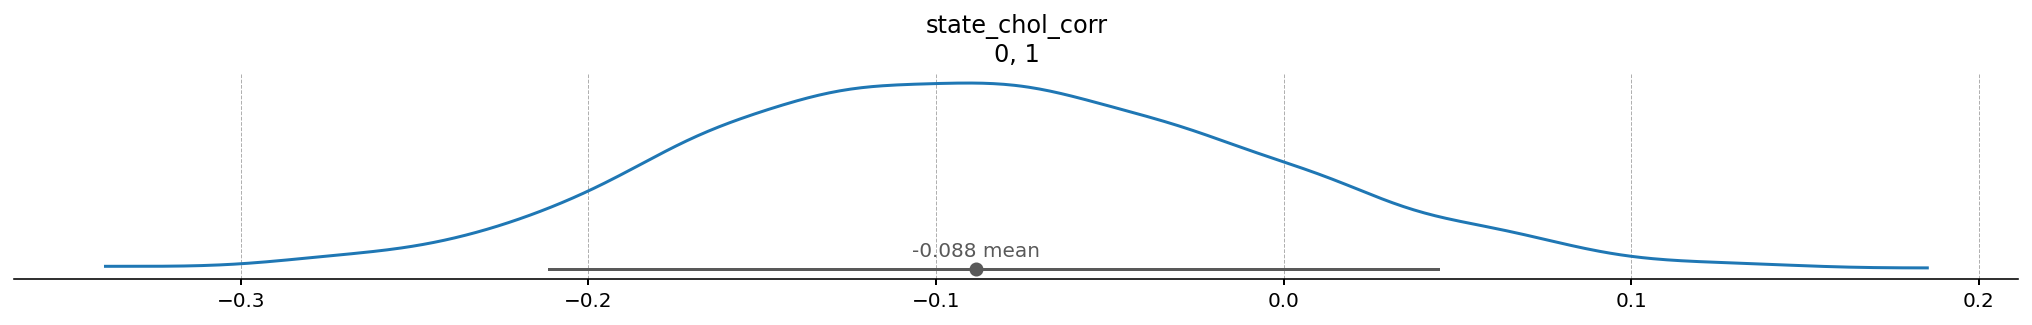

In [44]:
az.plot_dist(
    idata_joint,
    var_names=["state_chol_corr"],
    coords={"state_chol_corr_dim_0": [0], "state_chol_corr_dim_1": [1]},
)
plt.show()

Next we plot the predictions. Both models chose levels close to the most recent observation, with little or no trend. The volume appears to be bending upwards because of the use of multiplicative errors (we apply `np.exp` to the posterior forecasts samples to get back to the data scale)

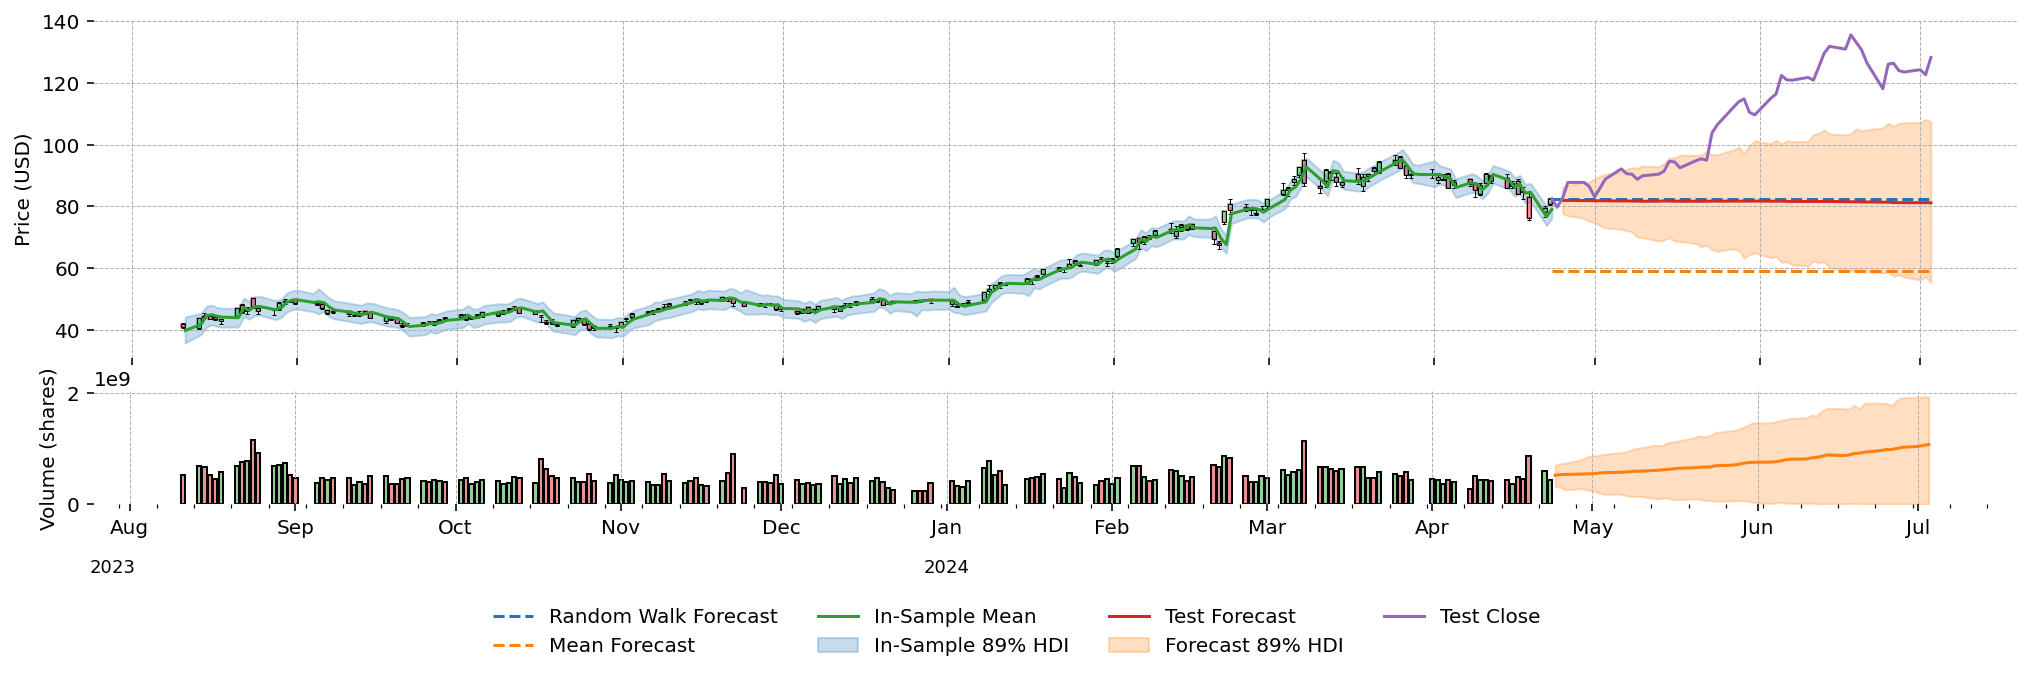

In [45]:
fig = plot_candlesticks_with_forecast(
    df_train,
    df_test,
    idata=idata_joint_post,
    idata_forecast=idata_joint_forecast,
    draw_rw=True,
    draw_mean=True,
)

# The volume model is fit in logs, so exponentiate the forecast to get back to share counts.
vol_ax = fig.axes[1]
vol_hat = np.exp(idata_joint_forecast.forecast_observed.sel(observed_state="Volume"))
vol_hdi = az.hdi(vol_hat, prob=CI_PROB)
forecast_idx = idata_joint_forecast.indexes["time"]

vol_ax.plot(forecast_idx, vol_hat.mean(dim=["chain", "draw"]), color="tab:orange")
vol_ax.fill_between(forecast_idx, *vol_hdi.values.T, alpha=0.25, color="tab:orange")
plt.show()

#### Decomposition

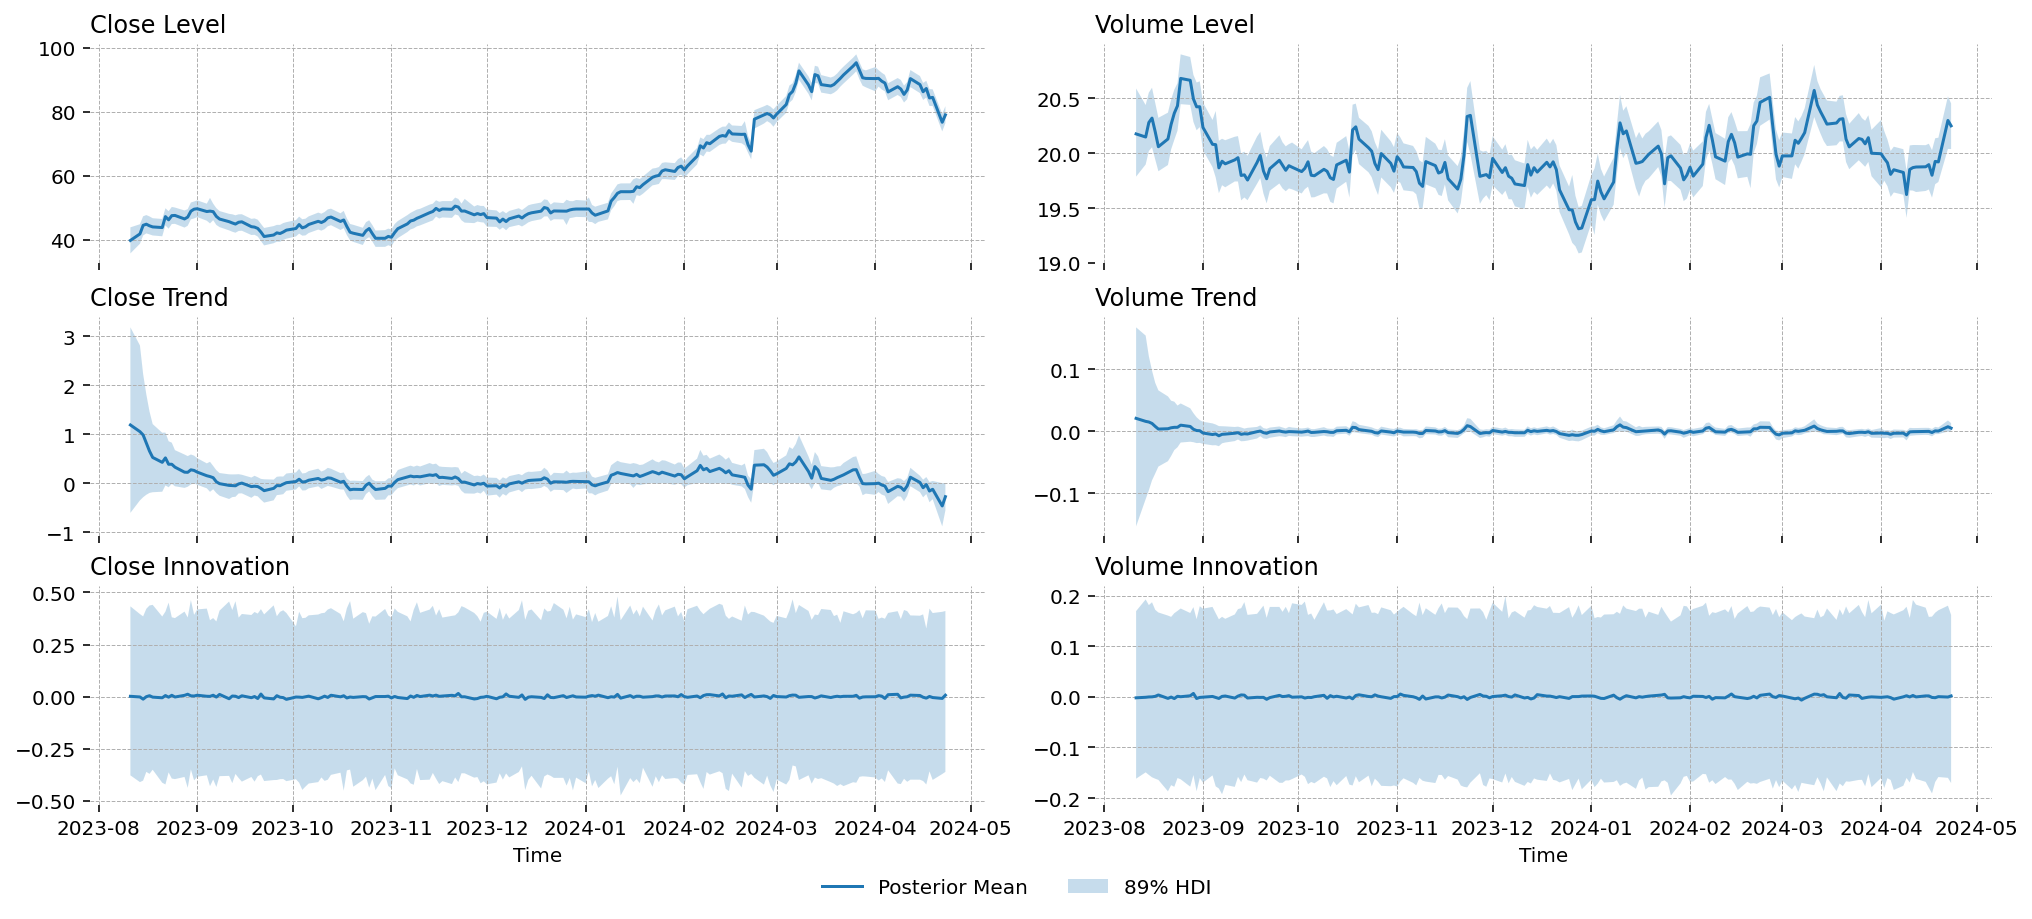

In [46]:
plot_decomposition(
    idata_joint_post.predicted_posterior,
    state_names=[
        f"{series}_{state}"
        for series in ["Close", "Volume"]
        for state in ["level", "trend", "innovation"]
    ],
    n_rows=3,
    n_cols=2,
)
plt.show()

## Bonus: Seasonality

There is no reason to believe that there are seasonal patterns in stock price data. To demonstrate how seasonality works, we turn to a different dataset: the well-studied airline passengers series, a monthly count of international airline passengers between 1949 and 1960.

In [47]:
airpass = (
    pd.read_csv("../tests/statespace/_data/airpassangers.csv", parse_dates=["Month"])
    .rename(columns={"Month": "time", "#Passengers": "passengers"})
    .set_index("time")
    .astype(float)
)

# The index is regular but carries no frequency, and the forecast horizon below is expressed as a
# shift of it.
airpass.index.freq = airpass.index.inferred_freq

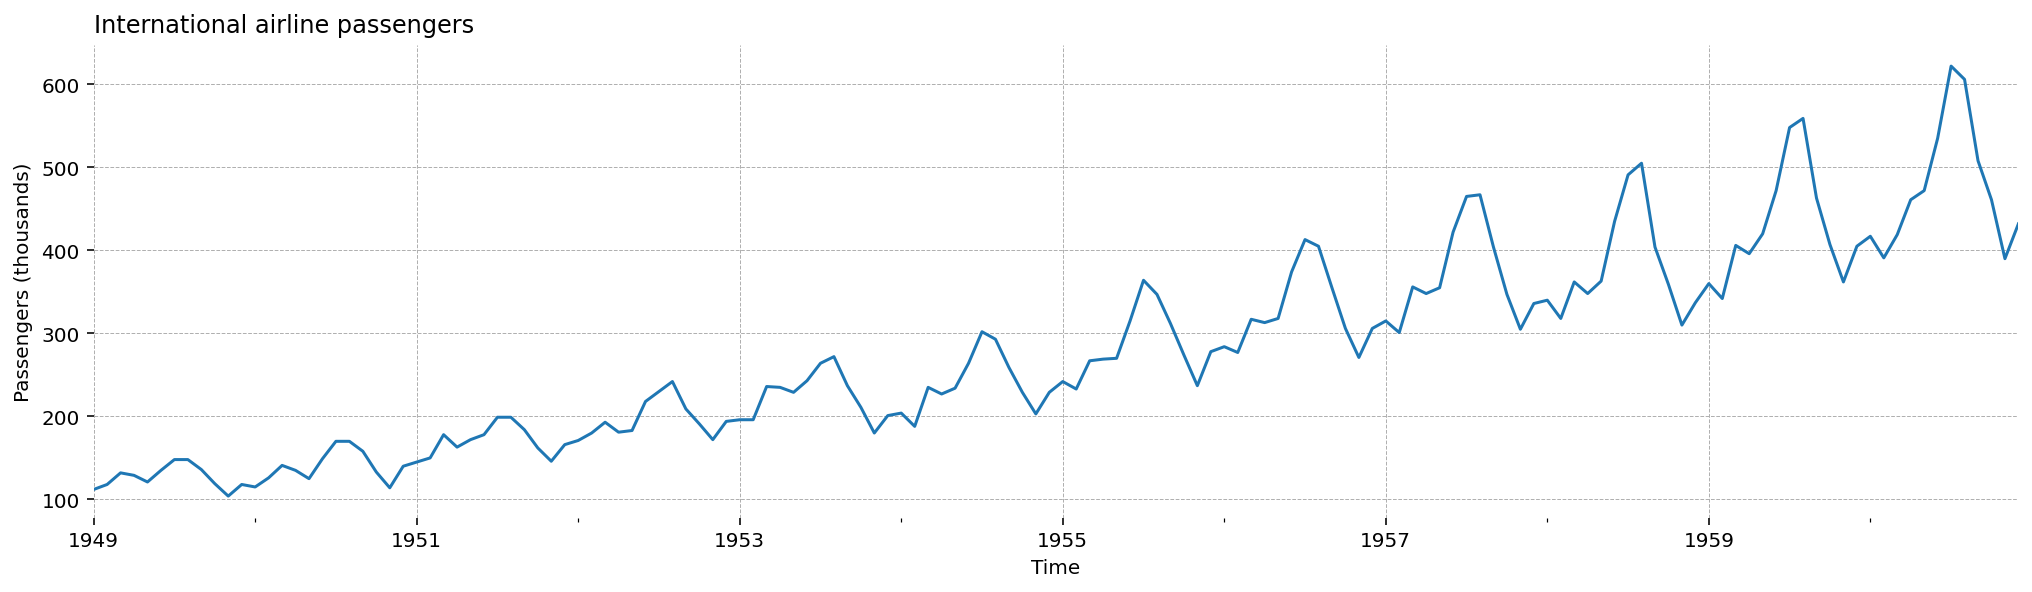

In [48]:
ax = airpass.plot(legend=False)
ax.set(xlabel="Time", ylabel="Passengers (thousands)")
ax.set_title("International airline passengers", loc="left")
plt.show()

The data appear to have increasing variance over time, which is the tell-tale sign of multiplicative errors. As a result, we model the log of the data, then exponentiate the outputs.

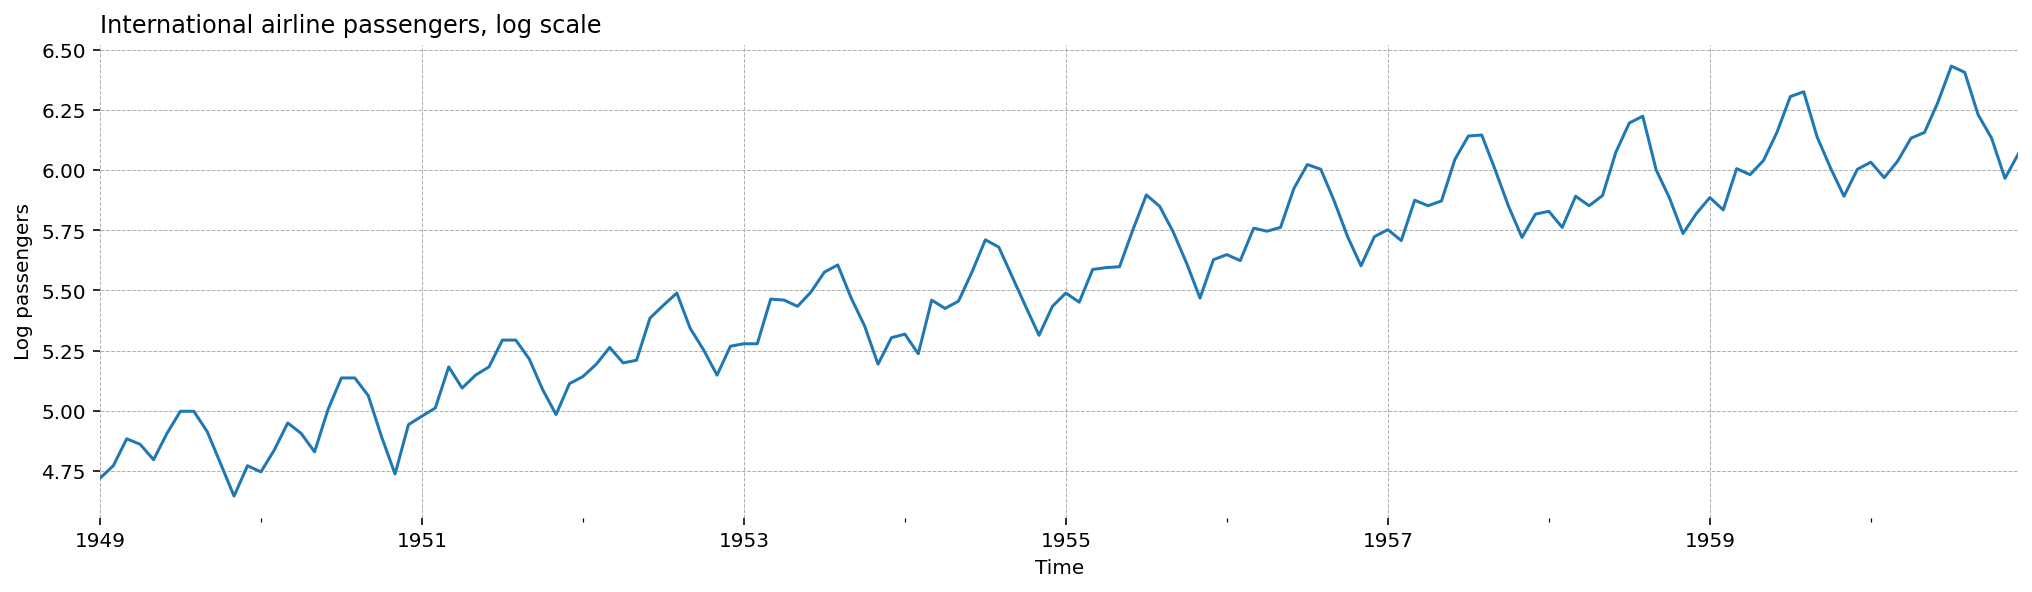

In [49]:
log_airpass = airpass.map(np.log)

ax = log_airpass.plot(legend=False)
ax.set(xlabel="Time", ylabel="Log passengers")
ax.set_title("International airline passengers, log scale", loc="left")
plt.show()

In [50]:
airpass_ss_mod = pmss.BayesianETS(
    endog_names=["Passengers"],
    order=("A", "Ad", "A"),
    seasonal_periods=12,
)

                       Model Requirements                       
                                                                
  Variable           Shape   Constraints            Dimensions  
 ────────────────────────────────────────────────────────────── 
  initial_level      ()                                   None  
  initial_trend      ()                                   None  
  initial_seasonal   (12,)                   ('seasonal_lag',)  
  alpha              ()      0 < alpha < 1                None  
  beta               ()      0 < beta < 1                 None  
  gamma              ()      0 < gamma < 1                None  
  phi                ()      0 < phi < 1                  None  
  sigma_state        ()      Positive                     None  
                                                                
 These parameters should be assigned priors inside a PyMC model 
    block before calling the build_statespace_graph method.     

In [51]:
with pm.Model(coords=airpass_ss_mod.coords) as airpass_mod:
    initial_level = pm.Normal("initial_level", mu=0, sigma=3)
    initial_trend = pm.Normal("initial_trend", mu=0, sigma=1)
    initial_seasonal = pm.ZeroSumNormal("initial_seasonal", sigma=1, dims=["seasonal_lag"])

    alpha = pm.Beta("alpha", alpha=1, beta=1)
    beta = pm.Beta("beta", alpha=1, beta=1)
    gamma = pm.Beta("gamma", alpha=1, beta=1)

    phi_params = pz.maxent(pz.Beta(), lower=0.85, upper=0.98, plot=False).params_dict
    phi = pm.Beta("phi", **phi_params)

    sigma_state = pm.Exponential("sigma_state", lam=1)

    airpass_ss_mod.build_statespace_graph(data=log_airpass)

    idata_airpass = pm.sample(**SAMPLER_KWARGS)

NUTS[nutpie]: [initial_level, initial_trend, initial_seasonal, alpha, beta, gamma, phi, sigma_state]


Output()

In [52]:
idata_airpass_post = airpass_ss_mod.sample_conditional_posterior(idata_airpass)
idata_airpass_forecast = airpass_ss_mod.forecast(
    idata_airpass, start=airpass.index[-1], end=airpass.index.shift(36)[-1]
)

Sampling: [filtered_posterior, filtered_posterior_observed, predicted_posterior, predicted_posterior_observed, smoothed_posterior, smoothed_posterior_observed]


Output()

Sampling: [forecast_combined]


Output()

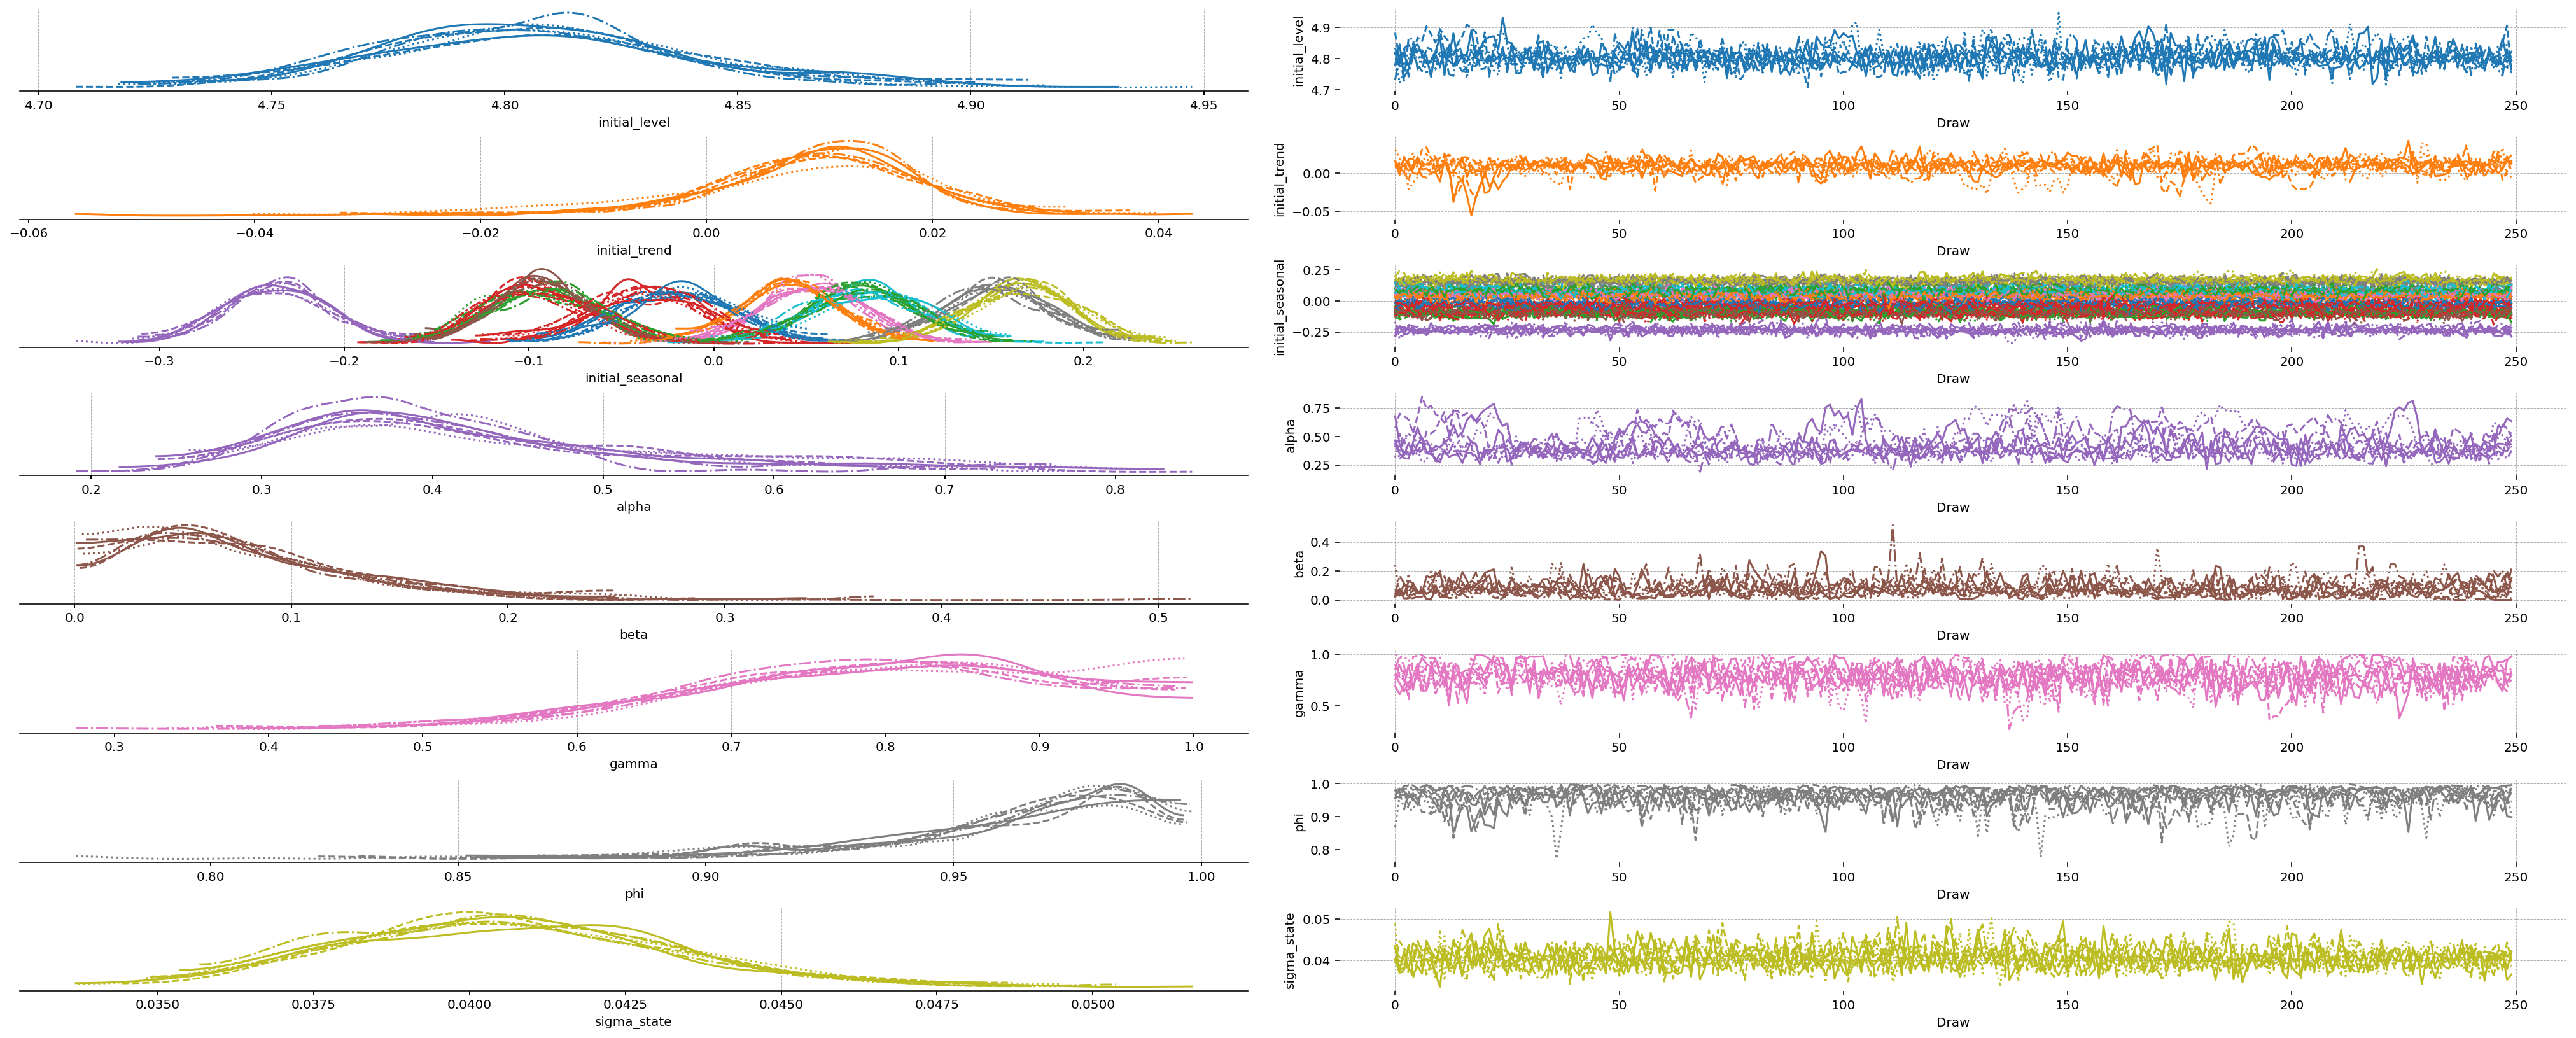

In [53]:
az.plot_trace_dist(idata_airpass, var_names=[x.name for x in airpass_mod.free_RVs])
plt.show()

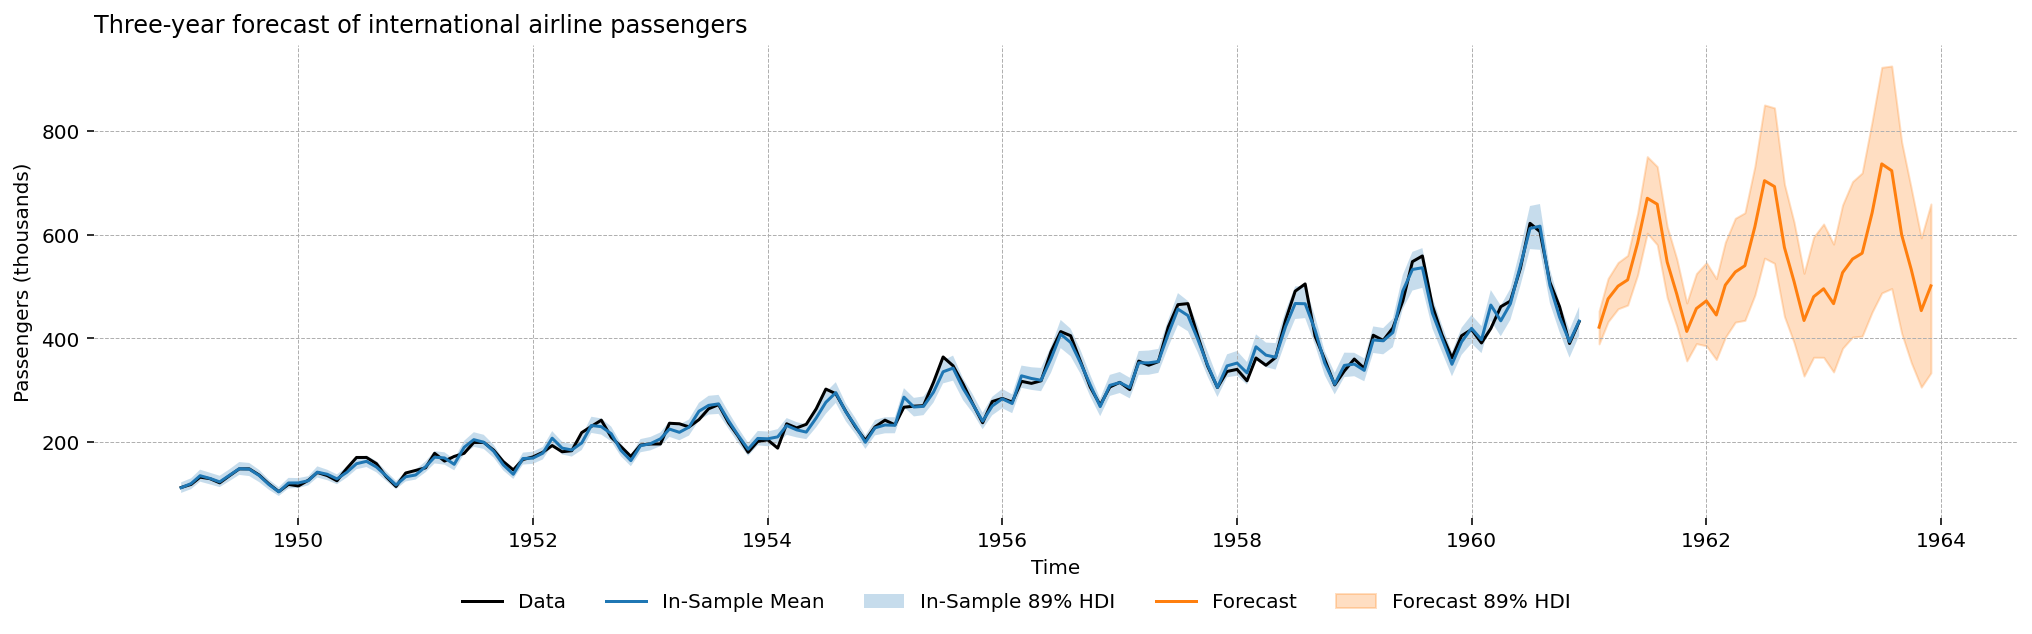

In [54]:
airpass_post = np.exp(idata_airpass_post.predicted_posterior_observed.isel(observed_state=0))
airpass_forecast = np.exp(
    idata_airpass_forecast.forecast_observed.isel(observed_state=0, time=slice(1, None))
)
forecast_idx = idata_airpass_forecast.indexes["time"][1:]

fig, ax = plt.subplots()

ax.plot(airpass.index, airpass.passengers, c="k", label="Data")
ax.plot(airpass.index, airpass_post.mean(dim=["chain", "draw"]), label="In-Sample Mean")
ax.fill_between(
    airpass.index,
    *az.hdi(airpass_post, prob=CI_PROB).values.T,
    alpha=0.25,
    label=f"In-Sample {CI_LABEL}",
)

ax.plot(
    forecast_idx,
    airpass_forecast.mean(dim=["chain", "draw"]),
    color="tab:orange",
    label="Forecast",
)
ax.fill_between(
    forecast_idx,
    *az.hdi(airpass_forecast, prob=CI_PROB).values.T,
    alpha=0.25,
    color="tab:orange",
    label=f"Forecast {CI_LABEL}",
)

ax.set(xlabel="Time", ylabel="Passengers (thousands)")
ax.set_title("Three-year forecast of international airline passengers", loc="left")

handles, labels = ax.get_legend_handles_labels()
fig.legend(
    handles=handles,
    labels=labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.08),
    ncol=len(labels),
    frameon=False,
)
plt.show()

#### Decomposition

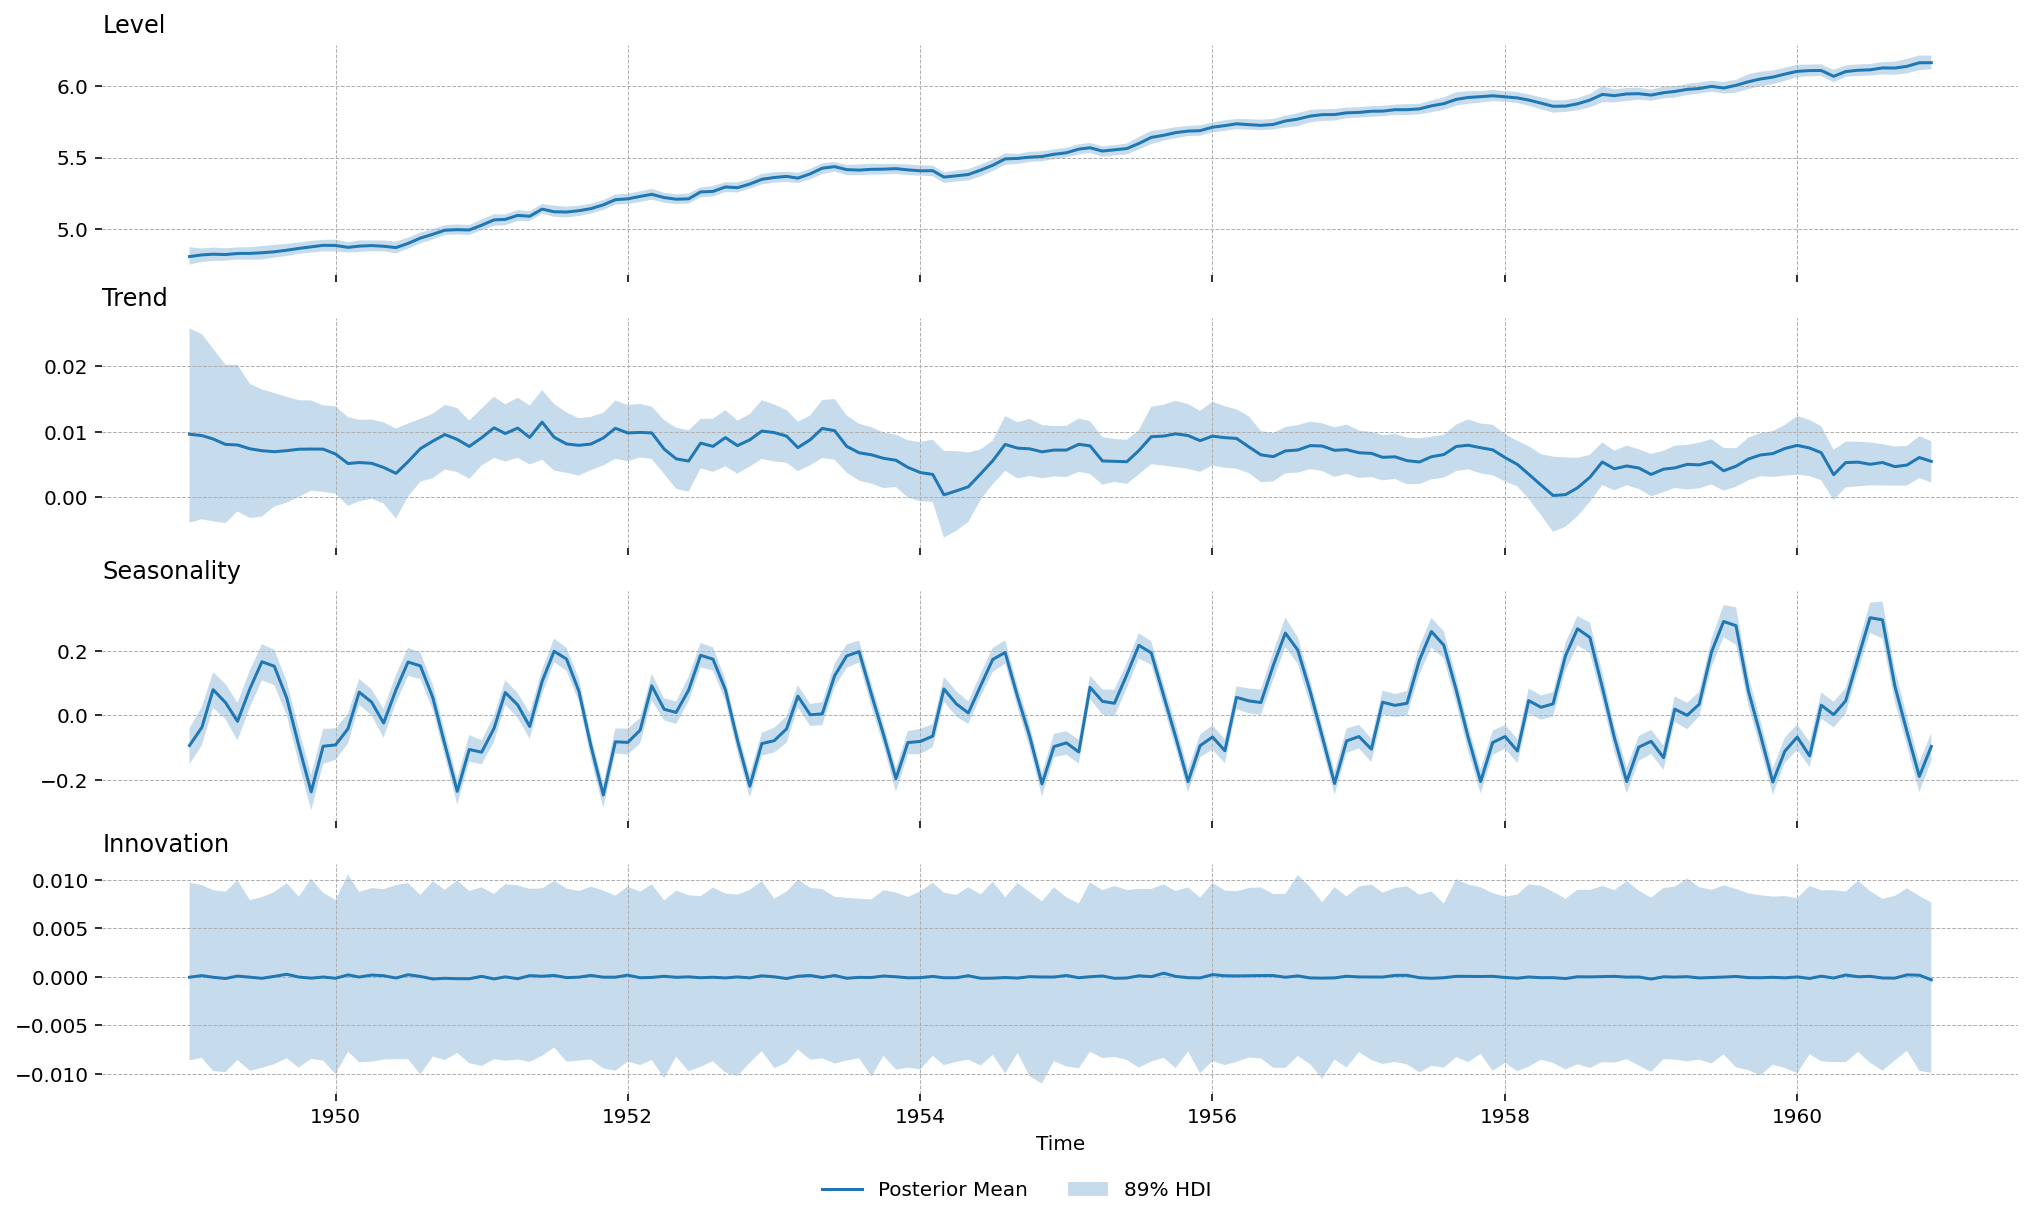

In [55]:
plot_decomposition(
    idata_airpass_post.predicted_posterior,
    state_names=["level", "trend", "seasonality", "innovation"],
    n_rows=4,
    n_cols=1,
    figsize=(14, 8),
)
plt.show()

## References

<a name="Brown1959"></a>
**Brown, Robert G.** *Statistical Forecasting for Inventory Control*. McGraw-Hill, 1959.

<a name="Holt1957"></a>
**Holt, Charles C.** "Forecasting Seasonals and Trends by Exponentially Weighted Averages." *ONR Memorandum No. 52*, Carnegie Institute of Technology, 1957. Reprinted in *International Journal of Forecasting*, 2004. https://doi.org/10.1016/j.ijforecast.2003.09.015

<a name="Winters1960"></a>
**Winters, Peter R.** "Forecasting Sales by Exponentially Weighted Moving Averages." *Management Science*, vol. 6, no. 3, 1960, pp. 324-42. https://doi.org/10.1287/mnsc.6.3.324

<a name="ffp3"></a>
**Hyndman, Rob J., and George Athanasopoulos**. "Forecasting: Principles and Practice. 3rd ed.", *OTexts*, 2021, https://otexts.com/fpp3/.